In [ ]:
# Cell 1: Fair-Flow - Two-Objective RL for Throughput-Fairness Tradeoff Analysis
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import gymnasium as gym
from gymnasium import spaces
from enum import Enum, IntEnum
import heapq
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import seaborn as sns
from scipy.spatial.distance import cdist
import warnings
import datetime
warnings.filterwarnings('ignore')

# Additional imports for attention mechanism and advanced features
import torch.nn.init as init
from torch.nn import MultiheadAttention
from torch.distributions import Categorical

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Vehicle Type Definitions (4 types, no emergency vehicles)
class VehicleType(IntEnum):
    PUBLIC_TRANSIT = 0  # Buses, Trams (Priority for public good)
    PRIVATE_CAR = 1     # Regular cars (Standard)
    TRUCK = 2           # Delivery trucks, cargo (Heavy vehicles)
    MOTORCYCLE = 3      # Motorcycles, scooters (Agile)

# Vehicle characteristics configuration
@dataclass
class VehicleConfig:
    """Configuration for different vehicle types"""
    type: VehicleType
    priority: float  # 0.0 (lowest) to 1.0 (highest) - for soft prioritization
    avg_speed: float  # Average speed in cells/timestep
    size: float  # Space occupied (1.0 for car, 2.0 for bus/truck)
    acceleration: float  # Acceleration capability
    deceleration: float  # Braking capability
    base_wait_tolerance: int  # Baseline acceptable wait time

# Define vehicle configurations with fairness considerations
VEHICLE_CONFIGS = {
    VehicleType.PUBLIC_TRANSIT: VehicleConfig(
        type=VehicleType.PUBLIC_TRANSIT,
        priority=0.7,  # Higher priority (serves many people)
        avg_speed=0.8,
        size=2.0,
        acceleration=0.4,
        deceleration=0.5,
        base_wait_tolerance=25
    ),
    VehicleType.PRIVATE_CAR: VehicleConfig(
        type=VehicleType.PRIVATE_CAR,
        priority=0.5,
        avg_speed=1.0,
        size=1.0,
        acceleration=0.6,
        deceleration=0.7,
        base_wait_tolerance=30
    ),
    VehicleType.TRUCK: VehicleConfig(
        type=VehicleType.TRUCK,
        priority=0.4,  # Lower priority but important for economy
        avg_speed=0.7,
        size=2.5,
        acceleration=0.3,
        deceleration=0.4,
        base_wait_tolerance=40
    ),
    VehicleType.MOTORCYCLE: VehicleConfig(
        type=VehicleType.MOTORCYCLE,
        priority=0.5,
        avg_speed=1.2,
        size=0.5,
        acceleration=0.9,
        deceleration=0.8,
        base_wait_tolerance=25
    ),
}

# Experience tuple for prioritized replay
Experience = namedtuple('Experience',
                        ['state', 'action', 'reward', 'next_state', 'done',
                         'vehicle_types', 'fairness_metrics'])

# Hyperparameters for Fair-Flow: Two-Objective RL
class Config:
    """Configuration for Fair-Flow: Throughput-Fairness Tradeoff Analysis"""
    # Network architecture
    hidden_dim = 256
    attention_heads = 8
    attention_dim = 128
    dropout_rate = 0.1

    # DQN parameters
    learning_rate = 0.0005
    gamma = 0.99
    epsilon_start = 1.0
    epsilon_end = 0.01
    epsilon_decay = 0.995
    target_update = 10

    # Prioritized experience replay
    buffer_size = 100000
    batch_size = 64
    alpha = 0.6  # Priority exponent
    beta_start = 0.4  # Importance sampling weight
    beta_end = 1.0
    beta_annealing_steps = 100000

    # Two-objective reward weights (Throughput + Fairness only)
    throughput_weight = 0.45     # Total vehicles served (secondary)
    fairness_weight = 0.50       # Equity across vehicle types (primary)
    wait_penalty_weight = 0.05   # Excessive wait penalties (minor)

    # Fairness parameters
    fairness_window = 50  # Episodes to calculate rolling fairness
    target_jain_index = 0.85  # Target fairness (1.0 = perfect)
    fairness_threshold = 0.70  # Minimum acceptable fairness

    # Temporal features
    use_temporal_features = True
    time_of_day_bins = 24  # Hour-level granularity
    day_of_week_bins = 7
    history_window = 10  # Steps of history to track

    # Traffic environment
    grid_size = 10
    max_vehicles = 50

    # Spawn probabilities for different vehicle types
    spawn_probs = {
        VehicleType.PUBLIC_TRANSIT: 0.08,
        VehicleType.PRIVATE_CAR: 0.25,
        VehicleType.TRUCK: 0.12,
        VehicleType.MOTORCYCLE: 0.15,
    }

config = Config()

# Fairness metrics helper functions
def calculate_jains_fairness_index(values):
    """
    Calculate Jain's Fairness Index
    J = (Σxi)² / (n·Σxi²)
    Returns value between 0 (unfair) and 1 (perfectly fair)
    """
    if len(values) == 0 or sum(values) == 0:
        return 1.0
    n = len(values)
    sum_x = sum(values)
    sum_x_squared = sum(x**2 for x in values)
    return (sum_x ** 2) / (n * sum_x_squared) if sum_x_squared > 0 else 1.0

def calculate_gini_coefficient(values):
    """
    Calculate Gini coefficient for inequality measurement
    Returns value between 0 (perfect equality) and 1 (perfect inequality)
    """
    if len(values) == 0:
        return 0.0
    sorted_values = sorted(values)
    n = len(sorted_values)
    cumsum = np.cumsum(sorted_values)
    return (2 * sum((i + 1) * val for i, val in enumerate(sorted_values))) / (n * sum(sorted_values)) - (n + 1) / n if sum(sorted_values) > 0 else 0.0

print("=" * 80)
print("🚦 Fair-Flow: Two-Objective Traffic Control System")
print("=" * 80)
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"\n📊 Vehicle Types: {len(VehicleType)}")
for vtype in VehicleType:
    config_vt = VEHICLE_CONFIGS[vtype]
    print(f"  - {vtype.name:15s}: Priority={config_vt.priority:.1f}, Size={config_vt.size:.1f}")

print(f"\n🎯 Two-Objective Optimization:")
print(f"  ┌─ PRIMARY: Fairness Weight = {config.fairness_weight:.2f}")
print(f"  ├─ SECONDARY: Throughput Weight = {config.throughput_weight:.2f}")
print(f"  └─ MINOR: Wait Penalty Weight = {config.wait_penalty_weight:.2f}")

print(f"\n⚖️  Fairness Configuration:")
print(f"  - Target Jain's Index: {config.target_jain_index:.2f}")
print(f"  - Minimum Threshold: {config.fairness_threshold:.2f}")
print(f"  - Rolling Window: {config.fairness_window} episodes")

print(f"\n⏰ Temporal Features: {'Enabled' if config.use_temporal_features else 'Disabled'}")
if config.use_temporal_features:
    print(f"  - Time granularity: {config.time_of_day_bins} hours")
    print(f"  - History window: {config.history_window} steps")

print(f"\n📝 Research Focus:")
print(f"  Understanding the throughput-fairness tradeoff in")
print(f"  heterogeneous traffic systems with vehicle equity")

print("=" * 80)

🚦 Fair-Flow: Two-Objective Traffic Control System
Device: cuda
PyTorch version: 2.10.0+cu128
NumPy version: 2.0.2

📊 Vehicle Types: 4
  - PUBLIC_TRANSIT : Priority=0.7, Size=2.0
  - PRIVATE_CAR    : Priority=0.5, Size=1.0
  - TRUCK          : Priority=0.4, Size=2.5
  - MOTORCYCLE     : Priority=0.5, Size=0.5

🎯 Two-Objective Optimization:
  ┌─ PRIMARY: Fairness Weight = 0.50
  ├─ SECONDARY: Throughput Weight = 0.45
  └─ MINOR: Wait Penalty Weight = 0.05

⚖️  Fairness Configuration:
  - Target Jain's Index: 0.85
  - Minimum Threshold: 0.70
  - Rolling Window: 50 episodes

⏰ Temporal Features: Enabled
  - Time granularity: 24 hours
  - History window: 10 steps

📝 Research Focus:
  Understanding the throughput-fairness tradeoff in
  heterogeneous traffic systems with vehicle equity


In [ ]:
# Cell 2: Fair-Flow Environment - Two-Objective Optimization (Throughput + Fairness)
class FairFlowTrafficEnvironment(gym.Env):
    """Two-objective traffic environment: Throughput vs Fairness tradeoff"""

    def __init__(self, config=None):
        super().__init__()

        # Enhanced configuration
        self.config = config or Config()
        self.max_queue_length = 20
        self.episode_length = 200
        self.min_phase_duration = 3  # Minimum green time for stability

        # Action space: 0=keep current phase, 1=switch phase
        self.action_space = spaces.Discrete(2)

        # Enhanced state space with temporal features
        # Base: [4 dirs x 4 vehicle types = 16] + [4 avg wait times] + [2 phase info]
        # Fairness: [4 vehicle type fairness metrics]
        # Temporal: [2 time encoding] + [8 arrival history]
        # Total: 16 + 4 + 2 + 4 + 2 + 8 = 36 dimensions
        state_dim = 36 if config.use_temporal_features else 26
        self.observation_space = spaces.Box(
            low=0, high=1,
            shape=(state_dim,), dtype=np.float32
        )

        # Vehicle-specific arrival rates (base rates, modified by time)
        self.base_arrival_rates = {
            VehicleType.PUBLIC_TRANSIT: config.spawn_probs[VehicleType.PUBLIC_TRANSIT],
            VehicleType.PRIVATE_CAR: config.spawn_probs[VehicleType.PRIVATE_CAR],
            VehicleType.TRUCK: config.spawn_probs[VehicleType.TRUCK],
            VehicleType.MOTORCYCLE: config.spawn_probs[VehicleType.MOTORCYCLE]
        }

        # Direction names for clarity
        self.directions = ['North', 'South', 'East', 'West']

        # Service rates based on vehicle type (vehicles/timestep)
        self.service_rates = {
            VehicleType.PUBLIC_TRANSIT: 0.5,  # Slower due to size
            VehicleType.PRIVATE_CAR: 1.0,
            VehicleType.TRUCK: 0.4,  # Slowest
            VehicleType.MOTORCYCLE: 1.5  # Fastest
        }

        # Temporal tracking
        self.current_hour = 8  # Start at 8 AM
        self.current_day = 0  # Monday
        self.arrival_history = deque(maxlen=config.history_window)

        # Fairness tracking
        self.wait_time_by_type = {vt: [] for vt in VehicleType}
        self.service_time_by_type = {vt: [] for vt in VehicleType}

        self.reset()

    def reset(self, seed=None):
        if seed:
            np.random.seed(seed)
            random.seed(seed)

        # Initialize vehicle queues for each direction and type
        self.queues = {
            d: {vt: [] for vt in VehicleType}
            for d in range(4)
        }

        # Wait time trackers
        self.wait_times = {d: 0 for d in range(4)}
        self.max_wait_times = {d: 0 for d in range(4)}

        # Phase management
        self.current_phase = 0  # 0: NS green, 1: EW green
        self.phase_timer = 0

        # Metrics tracking
        self.step_count = 0
        self.total_wait_time = 0
        self.vehicles_served = {vt: 0 for vt in VehicleType}

        # Fairness metrics
        self.wait_time_by_type = {vt: [] for vt in VehicleType}
        self.service_time_by_type = {vt: [] for vt in VehicleType}
        self.jains_index_history = []

        # Temporal state
        self.current_hour = 8  # 8 AM start
        self.current_day = 0  # Monday
        self.arrival_history = deque(maxlen=self.config.history_window)
        for _ in range(self.config.history_window):
            self.arrival_history.append({vt: 0 for vt in VehicleType})

        # Vehicle ID counter for tracking
        self.vehicle_id_counter = 0

        return self._get_state(), {}

    def _create_vehicle(self, vehicle_type):
        """Create a new vehicle with unique ID and properties"""
        self.vehicle_id_counter += 1
        return {
            'id': self.vehicle_id_counter,
            'type': vehicle_type,
            'wait_time': 0,
            'arrival_step': self.step_count,
            'priority': VEHICLE_CONFIGS[vehicle_type].priority,
            'size': VEHICLE_CONFIGS[vehicle_type].size
        }

    def _get_temporal_arrival_rate(self, vehicle_type, base_rate):
        """Adjust arrival rates based on time of day"""
        if not self.config.use_temporal_features:
            return base_rate

        # Peak hours: 7-9 AM, 5-7 PM
        hour = self.current_hour

        if vehicle_type == VehicleType.PRIVATE_CAR:
            if 7 <= hour <= 9 or 17 <= hour <= 19:
                return base_rate * 1.8  # Rush hour
            elif 22 <= hour or hour <= 6:
                return base_rate * 0.3  # Night
            else:
                return base_rate

        elif vehicle_type == VehicleType.TRUCK:
            if 10 <= hour <= 16:
                return base_rate * 1.5  # Daytime deliveries
            elif 22 <= hour or hour <= 6:
                return base_rate * 0.4  # Night
            else:
                return base_rate

        elif vehicle_type == VehicleType.PUBLIC_TRANSIT:
            if 6 <= hour <= 9 or 16 <= hour <= 19:
                return base_rate * 1.6  # Transit peak
            elif 23 <= hour or hour <= 5:
                return base_rate * 0.2  # Night
            else:
                return base_rate

        elif vehicle_type == VehicleType.MOTORCYCLE:
            if 22 <= hour or hour <= 6:
                return base_rate * 0.4  # Night
            else:
                return base_rate * 1.2  # Day

        return base_rate

    def _get_state(self):
        """Enhanced state representation with fairness and temporal features"""
        state = []

        # 1. Queue lengths by vehicle type for each direction (16 features)
        for d in range(4):
            for vt in VehicleType:
                count = len(self.queues[d][vt])
                normalized = min(count / self.max_queue_length, 1.0)
                state.append(normalized)

        # 2. Average wait times per direction (4 features)
        for d in range(4):
            total_vehicles = sum(len(self.queues[d][vt]) for vt in VehicleType)
            if total_vehicles > 0:
                avg_wait = sum(
                    sum(v['wait_time'] for v in self.queues[d][vt])
                    for vt in VehicleType
                ) / total_vehicles
                state.append(min(avg_wait / 50.0, 1.0))
            else:
                state.append(0.0)

        # 3. Current phase and timer (2 features)
        state.append(float(self.current_phase))
        state.append(min(self.phase_timer / 20.0, 1.0))

        # 4. Fairness metrics per vehicle type (4 features)
        # Average wait time ratio for each type compared to mean
        all_waits = []
        type_waits = {vt: [] for vt in VehicleType}
        for d in range(4):
            for vt in VehicleType:
                for vehicle in self.queues[d][vt]:
                    all_waits.append(vehicle['wait_time'])
                    type_waits[vt].append(vehicle['wait_time'])

        mean_wait = np.mean(all_waits) if all_waits else 1.0
        for vt in VehicleType:
            if type_waits[vt]:
                type_avg = np.mean(type_waits[vt])
                ratio = type_avg / max(mean_wait, 1.0)
                state.append(min(ratio, 2.0) / 2.0)  # Normalize
            else:
                state.append(0.5)  # Neutral

        # 5. Temporal features (if enabled)
        if self.config.use_temporal_features:
            # Time of day (2 features: sin/cos encoding for cyclical nature)
            hour_angle = 2 * np.pi * self.current_hour / 24
            state.append((np.sin(hour_angle) + 1) / 2)  # Normalize to [0, 1]
            state.append((np.cos(hour_angle) + 1) / 2)

            # Recent arrival trends (8 features: 2 most recent for each type)
            for vt in VehicleType:
                recent_arrivals = [self.arrival_history[i][vt]
                                  for i in range(-2, 0)]
                for arr in recent_arrivals:
                    state.append(min(arr / 5.0, 1.0))  # Normalize

        return np.array(state, dtype=np.float32)

    def _calculate_reward(self, action, info):
        """Two-objective reward: Throughput + Fairness"""
        reward = 0

        # 1. THROUGHPUT - Fair service reward
        vehicles_served_list = [
            info['vehicles_served'].get(vt, 0)
            for vt in VehicleType
        ]

        if sum(vehicles_served_list) > 0:
            # Calculate fairness of service distribution
            service_fairness = calculate_jains_fairness_index(
                [v + 1 for v in vehicles_served_list]  # +1 to avoid zeros
            )

            # Base throughput reward weighted by service fairness
            throughput_reward = sum(vehicles_served_list) * 2 * service_fairness

            # Bonus for serving public transit (serves many people)
            transit_served = info['vehicles_served'].get(VehicleType.PUBLIC_TRANSIT, 0)
            throughput_reward += transit_served * 3

            # Penalty for very imbalanced service
            max_served = max(vehicles_served_list)
            min_served = min(vehicles_served_list)
            if max_served > min_served * 3:  # 3x imbalance
                throughput_reward -= 100
        else:
            throughput_reward = 0

        reward += throughput_reward * self.config.throughput_weight

        # 2. FAIRNESS - Jain's Fairness Index on wait times
        wait_times_by_type = []
        for vt in VehicleType:
            type_waits = []
            for d in range(4):
                type_waits.extend([v['wait_time'] for v in self.queues[d][vt]])

            if type_waits:
                avg_wait = np.mean(type_waits)
                wait_times_by_type.append(avg_wait)
            else:
                wait_times_by_type.append(0.0)

        # Initialize with perfect fairness default
        jains_index = 1.0

        # Calculate Jain's index (higher is better)
        if sum(wait_times_by_type) > 0:
            jains_index = calculate_jains_fairness_index(wait_times_by_type)
            self.jains_index_history.append(jains_index)

            # Reward fairness: scale centered at 0.5
            fairness_reward = (jains_index - 0.5) * 200
            reward += fairness_reward * self.config.fairness_weight

        # CRITICAL: Hard penalty if fairness below threshold
        if jains_index < self.config.fairness_threshold:
            penalty = 500 * (self.config.fairness_threshold - jains_index)
            reward -= penalty

        # Bonus for achieving target fairness
        if jains_index >= self.config.target_jain_index:
            reward += 200

        # 3. WAIT TIME PENALTIES - Excessive waits
        wait_penalty = 0
        for d in range(4):
            for vt in VehicleType:
                tolerance = VEHICLE_CONFIGS[vt].base_wait_tolerance
                for vehicle in self.queues[d][vt]:
                    if vehicle['wait_time'] > tolerance:
                        excess = vehicle['wait_time'] - tolerance
                        wait_penalty += excess * 0.5

        reward -= wait_penalty * self.config.wait_penalty_weight

        # 4. QUEUE OVERFLOW SAFETY
        max_queue = max(
            sum(len(self.queues[d][vt]) for vt in VehicleType)
            for d in range(4)
        )

        if max_queue >= self.max_queue_length * 0.9:
            reward -= 100  # Big penalty for near-overflow

        return reward

    def step(self, action):
        """Step with fairness tracking and temporal dynamics"""
        switched = False

        # Handle actions
        if action == 0:  # Keep current phase
            pass
        elif action == 1 and self.phase_timer >= self.min_phase_duration:
            self.current_phase = 1 - self.current_phase
            self.phase_timer = 0
            switched = True

        # Update timers
        self.phase_timer += 1
        self.step_count += 1

        # Update time of day (1 step = ~30 seconds, 120 steps = 1 hour)
        if self.config.use_temporal_features and self.step_count % 120 == 0:
            self.current_hour = (self.current_hour + 1) % 24
            if self.current_hour == 0:
                self.current_day = (self.current_day + 1) % 7

        # Track arrivals for this step
        arrivals_this_step = {vt: 0 for vt in VehicleType}

        # Generate new vehicle arrivals with temporal variation
        for d in range(4):
            for vt in VehicleType:
                base_rate = self.base_arrival_rates[vt]
                actual_rate = self._get_temporal_arrival_rate(vt, base_rate)

                if np.random.random() < actual_rate:
                    # Congestion-based throttling
                    total_in_dir = sum(len(self.queues[d][v]) for v in VehicleType)
                    if total_in_dir < self.max_queue_length * 0.9:
                        new_vehicle = self._create_vehicle(vt)
                        self.queues[d][vt].append(new_vehicle)
                        arrivals_this_step[vt] += 1

        self.arrival_history.append(arrivals_this_step)

        # Update wait times
        for d in range(4):
            for vt in VehicleType:
                for vehicle in self.queues[d][vt]:
                    vehicle['wait_time'] += 1
                    self.total_wait_time += 1

        # Serve vehicles based on current phase
        vehicles_served = {vt: 0 for vt in VehicleType}

        if self.current_phase == 0:  # North-South green
            active_directions = [0, 1]
        else:  # East-West green
            active_directions = [2, 3]

        for d in active_directions:
            served_this_cycle = 0
            max_serve = 3.5  # Total capacity per direction

            # Serve in priority order
            priority_order = [
                VehicleType.PUBLIC_TRANSIT,
                VehicleType.PRIVATE_CAR,
                VehicleType.MOTORCYCLE,
                VehicleType.TRUCK
            ]

            for vt in priority_order:
                if served_this_cycle >= max_serve:
                    break

                while self.queues[d][vt] and served_this_cycle < max_serve:
                    vehicle = self.queues[d][vt][0]
                    service_rate = self.service_rates[vt]

                    if np.random.random() < service_rate:
                        self.queues[d][vt].pop(0)
                        vehicles_served[vt] += 1
                        served_this_cycle += vehicle['size']
                        self.vehicles_served[vt] += 1

                        # Track service time for fairness
                        service_time = self.step_count - vehicle['arrival_step']
                        self.service_time_by_type[vt].append(service_time)
                        self.wait_time_by_type[vt].append(vehicle['wait_time'])
                    else:
                        break

        # Collect info
        info = {
            'vehicles_served': vehicles_served,
            'switched': switched,
            'total_queue': sum(len(self.queues[d][vt]) for d in range(4) for vt in VehicleType),
            'avg_wait_time': self.total_wait_time / max(self.step_count, 1),
            'jains_index': self.jains_index_history[-1] if self.jains_index_history else 0.0,
            'current_hour': self.current_hour
        }

        reward = self._calculate_reward(action, info)

        # Check termination
        done = (
            self.step_count >= self.episode_length or
            any(sum(len(self.queues[d][vt]) for vt in VehicleType) >= self.max_queue_length
                for d in range(4))
        )

        return self._get_state(), reward, done, False, info

print("=" * 80)
print("✅ Fair-Flow Two-Objective Environment Created!")
print("=" * 80)
print(f"📊 State dimensions: {36 if config.use_temporal_features else 26}")
print(f"🎮 Actions: 2 (Keep/Switch)")
print(f"🚗 Vehicle types: {len(VehicleType)}")
print(f"\n🎯 Objectives:")
print(f"   1. Throughput (45% weight) - Total vehicles served")
print(f"   2. Fairness (50% weight) - Equity across vehicle types")
print(f"   3. Wait Penalty (5% weight) - Regularization")
print("=" * 80)

✅ Fair-Flow Two-Objective Environment Created!
📊 State dimensions: 36
🎮 Actions: 2 (Keep/Switch)
🚗 Vehicle types: 4

🎯 Objectives:
   1. Throughput (45% weight) - Total vehicles served
   2. Fairness (50% weight) - Equity across vehicle types
   3. Wait Penalty (5% weight) - Regularization


In [ ]:
# Cell 3: Fair-Flow Two-Objective DQN with Attention and Fairness Optimization
class SpatialTemporalAttention(nn.Module):
    """Spatial-temporal attention mechanism for traffic patterns"""
    def __init__(self, input_dim, hidden_dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim

        self.spatial_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.1,
            batch_first=True
        )

        self.temporal_gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        # Project input to hidden_dim * 4 for 4 directions
        self.input_projection = nn.Linear(input_dim, hidden_dim * 4)
        self.spatial_norm = nn.LayerNorm(hidden_dim)
        self.temporal_norm = nn.LayerNorm(hidden_dim)
        # Positional encoding for 4 directions
        self.positional_encoding = nn.Parameter(torch.randn(1, 4, hidden_dim))

    def forward(self, x, return_attention=False):
        batch_size = x.size(0)
        x_proj = self.input_projection(x)
        # Reshape to (batch_size, 4 directions, hidden_dim)
        x_spatial = x_proj.view(batch_size, 4, self.hidden_dim)
        x_spatial = x_spatial + self.positional_encoding

        attn_output, attn_weights = self.spatial_attention(
            x_spatial, x_spatial, x_spatial
        )
        x_spatial = self.spatial_norm(x_spatial + attn_output)

        x_temporal, _ = self.temporal_gru(x_spatial)
        x_temporal = self.temporal_norm(x_spatial + x_temporal)

        output = x_temporal.view(batch_size, -1)

        if return_attention:
            return output, attn_weights
        return output

class DuelingNetwork(nn.Module):
    """Dueling architecture for value and advantage estimation"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        features = self.feature_layer(x)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        # Dueling: Q = V + (A - mean(A))
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))
        return q_values

class FairnessPredictor(nn.Module):
    """Predicts fairness metrics from state for auxiliary learning"""
    def __init__(self, state_size, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, len(VehicleType))  # Predict wait time fairness per type
        )

    def forward(self, x):
        return torch.sigmoid(self.network(x))  # Normalized fairness scores

class FairFlowDQN(nn.Module):
    """Fair-Flow: Attention-Enhanced Dueling DQN with Fairness Awareness"""
    def __init__(self, state_size=36, action_size=2, config=None):
        super().__init__()
        self.config = config or Config()
        self.state_size = state_size
        self.action_size = action_size

        # Network dimensions
        self.hidden_dim = 128
        self.attention_heads = 4

        # Spatial-temporal attention for traffic patterns
        self.attention = SpatialTemporalAttention(
            input_dim=state_size,
            hidden_dim=self.hidden_dim,
            num_heads=self.attention_heads
        )

        # Dueling network for Q-values
        attention_output_dim = self.hidden_dim * 4
        self.dueling_network = DuelingNetwork(
            input_dim=attention_output_dim,
            hidden_dim=self.hidden_dim,
            output_dim=action_size
        )

        # Fairness predictor (auxiliary task)
        self.fairness_predictor = FairnessPredictor(
            state_size=state_size,
            hidden_dim=64
        )

        # Vehicle type embedding for richer representations
        self.vehicle_embedding = nn.Embedding(len(VehicleType), 16)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, x, return_features=False):
        # Attention-enhanced features
        attended_features = self.attention(x)

        # Q-values from dueling network
        q_values = self.dueling_network(attended_features)

        # Fairness predictions (auxiliary)
        fairness_scores = self.fairness_predictor(x)

        if return_features:
            return q_values, fairness_scores, attended_features
        return q_values, fairness_scores

class PrioritizedReplayBuffer:
    """Prioritized Experience Replay for efficient learning"""
    def __init__(self, capacity, alpha=0.6, beta_start=0.4):
        self.capacity = capacity
        self.alpha = alpha
        self.beta = beta_start
        self.beta_increment = 0.00001

        self.buffer = []
        self.priorities = np.zeros((capacity,), dtype=np.float32)
        self.position = 0
        self.max_priority = 1.0

    def push(self, experience):
        max_priority = self.priorities.max() if self.buffer else self.max_priority

        if len(self.buffer) < self.capacity:
            self.buffer.append(experience)
        else:
            self.buffer[self.position] = experience

        self.priorities[self.position] = max_priority
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        if len(self.buffer) == self.capacity:
            priorities = self.priorities
        else:
            priorities = self.priorities[:self.position]

        probabilities = priorities ** self.alpha
        probabilities /= probabilities.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probabilities)
        experiences = [self.buffer[idx] for idx in indices]

        total = len(self.buffer)
        weights = (total * probabilities[indices]) ** (-self.beta)
        weights /= weights.max()

        self.beta = min(1.0, self.beta + self.beta_increment)

        return experiences, indices, weights

    def update_priorities(self, indices, td_errors):
        for idx, td_error in zip(indices, td_errors):
            priority = min(abs(td_error) + 1e-6, 10.0)
            self.priorities[idx] = priority
            self.max_priority = max(self.max_priority, priority)

    def __len__(self):
        return len(self.buffer)

class FairFlowAgent:
    """Fair-Flow Agent: Two-Objective RL for Throughput-Fairness Tradeoff"""
    def __init__(self, state_size=36, action_size=2, config=None):
        self.state_size = state_size
        self.action_size = action_size
        self.config = config or Config()
        self.device = device

        # Initialize networks
        self.q_network = FairFlowDQN(state_size, action_size, self.config).to(self.device)
        self.target_network = FairFlowDQN(state_size, action_size, self.config).to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())

        # Optimizer with weight decay for regularization
        self.optimizer = optim.AdamW(
            self.q_network.parameters(),
            lr=self.config.learning_rate,
            weight_decay=1e-5
        )
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=2000, gamma=0.95
        )

        # Prioritized replay buffer
        self.memory = PrioritizedReplayBuffer(
            capacity=self.config.buffer_size,
            alpha=self.config.alpha,
            beta_start=self.config.beta_start
        )

        # Exploration parameters
        self.epsilon_start = self.config.epsilon_start
        self.epsilon_end = self.config.epsilon_end
        self.epsilon_decay_steps = 40000  # Slower decay for better exploration

        # Training parameters
        self.gamma = self.config.gamma
        self.batch_size = self.config.batch_size
        self.target_update_freq = 100
        self.training_start = 500

        # Tracking
        self.total_steps = 0
        self.episode = 0
        self.losses = []
        self.td_errors = []
        self.fairness_history = []
        self.jains_index_history = []

        print("=" * 80)
        print("🚦 Fair-Flow Two-Objective Agent Initialized")
        print("=" * 80)
        print(f"📊 Architecture:")
        print(f"   - Total parameters: {sum(p.numel() for p in self.q_network.parameters()):,}")
        print(f"   - State size: {state_size}")
        print(f"   - Action size: {action_size}")
        print(f"   - Hidden dim: {self.q_network.hidden_dim}")
        print(f"   - Attention heads: {self.q_network.attention_heads}")
        print(f"\n🎯 Training Configuration:")
        print(f"   - Epsilon decay: {self.epsilon_decay_steps:,} steps")
        print(f"   - Learning rate: {self.config.learning_rate}")
        print(f"   - Gamma: {self.gamma}")
        print(f"   - Batch size: {self.batch_size}")
        print(f"   - Buffer size: {self.config.buffer_size:,}")
        print(f"\n🎯 Two-Objective Focus:")
        print(f"   - PRIMARY: Fairness (Jain's Index ≥ {self.config.target_jain_index})")
        print(f"   - SECONDARY: Throughput (balanced service)")
        print(f"\n⚙️  Device: {self.device}")
        print("=" * 80)

    def get_epsilon(self):
        """Linear epsilon decay based on steps"""
        if self.total_steps >= self.epsilon_decay_steps:
            return self.epsilon_end

        decay_progress = self.total_steps / self.epsilon_decay_steps
        current_epsilon = self.epsilon_start - (self.epsilon_start - self.epsilon_end) * decay_progress
        return current_epsilon

    def remember(self, state, action, reward, next_state, done, info=None):
        """Store experience with fairness metrics"""
        fairness_metrics = None
        if info:
            fairness_metrics = {
                'jains_index': info.get('jains_index', 0.0),
                'total_served': sum(info.get('vehicles_served', {}).values())
            }

        vehicle_types = info.get('vehicle_distribution', None) if info else None

        experience = Experience(
            state, action, reward, next_state, done,
            vehicle_types, fairness_metrics
        )
        self.memory.push(experience)

    def act(self, state, training=True):
        """Action selection with epsilon-greedy exploration"""
        self.total_steps += 1

        # Get current epsilon
        current_epsilon = self.get_epsilon() if training else 0.01

        # Epsilon-greedy exploration
        if training and np.random.random() < current_epsilon:
            return random.randint(0, self.action_size - 1)

        # Exploitation: select best action
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad():
            q_values, fairness_scores = self.q_network(state_tensor)

        return q_values.argmax().item()

    def replay(self):
        """Training with prioritized replay and fairness auxiliary loss"""
        if len(self.memory) < self.training_start:
            return None

        # Sample batch
        experiences, indices, weights = self.memory.sample(self.batch_size)

        # Prepare tensors
        states = torch.FloatTensor([e.state for e in experiences]).to(self.device)
        actions = torch.LongTensor([e.action for e in experiences]).to(self.device)
        rewards = torch.FloatTensor([e.reward for e in experiences]).to(self.device)
        next_states = torch.FloatTensor([e.next_state for e in experiences]).to(self.device)
        dones = torch.BoolTensor([e.done for e in experiences]).to(self.device)
        weights = torch.FloatTensor(weights).to(self.device)

        # Current Q values
        current_q_values, current_fairness = self.q_network(states)
        current_q_values = current_q_values.gather(1, actions.unsqueeze(1))

        # Double DQN: use online network to select action, target to evaluate
        with torch.no_grad():
            next_q_values_online, _ = self.q_network(next_states)
            next_actions = next_q_values_online.argmax(1)

            next_q_values_target, _ = self.target_network(next_states)
            next_q_values = next_q_values_target.gather(1, next_actions.unsqueeze(1))

            target_q_values = rewards.unsqueeze(1) + (self.gamma * next_q_values * ~dones.unsqueeze(1))

        # TD errors for priority update
        td_errors = (current_q_values - target_q_values).detach().cpu().numpy()

        # Main Q-learning loss (weighted by importance sampling)
        q_loss = (weights.unsqueeze(1) * F.smooth_l1_loss(
            current_q_values, target_q_values, reduction='none'
        )).mean()

        # Total loss (no auxiliary fairness loss for simplicity)
        total_loss = q_loss

        # Optimization
        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=1.0)
        self.optimizer.step()

        # Update priorities
        self.memory.update_priorities(indices, td_errors.squeeze())

        # Soft target network update
        if self.total_steps % self.target_update_freq == 0:
            tau = 0.005
            for target_param, param in zip(
                self.target_network.parameters(),
                self.q_network.parameters()
            ):
                target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

        # Learning rate scheduling
        if self.total_steps % 1000 == 0:
            self.scheduler.step()

        self.losses.append(total_loss.item())
        self.td_errors.extend(td_errors.squeeze().tolist())

        return total_loss.item()

    def get_advanced_stats(self):
        """Get comprehensive training statistics"""
        stats = {
            'epsilon': self.get_epsilon(),
            'memory_size': len(self.memory),
            'steps': self.total_steps,
            'beta': self.memory.beta,
            'learning_rate': self.optimizer.param_groups[0]['lr']
        }

        if self.losses:
            stats['avg_loss'] = np.mean(self.losses[-100:])
            stats['loss_std'] = np.std(self.losses[-100:])

        if self.td_errors:
            stats['avg_td_error'] = np.mean(np.abs(self.td_errors[-100:]))

        if self.jains_index_history:
            stats['avg_jains_index'] = np.mean(self.jains_index_history[-20:])
            stats['jains_trend'] = np.mean(self.jains_index_history[-10:]) - np.mean(self.jains_index_history[-20:-10]) if len(self.jains_index_history) >= 20 else 0

        return stats

    def save_model(self, filepath):
        """Save model checkpoint"""
        torch.save({
            'q_network': self.q_network.state_dict(),
            'target_network': self.target_network.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'total_steps': self.total_steps,
            'episode': self.episode
        }, filepath)
        print(f"💾 Model saved to {filepath}")

    def load_model(self, filepath):
        """Load model checkpoint"""
        checkpoint = torch.load(filepath, map_location=self.device)
        self.q_network.load_state_dict(checkpoint['q_network'])
        self.target_network.load_state_dict(checkpoint['target_network'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.total_steps = checkpoint['total_steps']
        self.episode = checkpoint['episode']
        print(f"📂 Model loaded from {filepath}")

print("\n" + "=" * 80)
print("✅ Fair-Flow Two-Objective DQN Agent Ready!")
print("=" * 80)
print("\n🎯 Key Features:")
print("   1. ✅ Spatial-temporal attention for traffic patterns")
print("   2. ✅ Dueling architecture (separate value/advantage)")
print("   3. ✅ Prioritized experience replay")
print("   4. ✅ Fairness-aware auxiliary prediction")
print("   5. ✅ Soft target updates (tau=0.005)")
print("   6. ✅ Linear epsilon decay over 40k steps")
print("   7. ✅ Two-objective reward (Throughput + Fairness)")
print("\n📊 Vehicle Types: 4 (Public Transit, Private Car, Truck, Motorcycle)")
print("🎮 Actions: 2 (Keep current phase, Switch phase)")
print("\n🎯 Research Focus:")
print("   Understanding the throughput-fairness tradeoff")
print("=" * 80)


✅ Fair-Flow Two-Objective DQN Agent Ready!

🎯 Key Features:
   1. ✅ Spatial-temporal attention for traffic patterns
   2. ✅ Dueling architecture (separate value/advantage)
   3. ✅ Prioritized experience replay
   4. ✅ Fairness-aware auxiliary prediction
   5. ✅ Soft target updates (tau=0.005)
   6. ✅ Linear epsilon decay over 40k steps
   7. ✅ Two-objective reward (Throughput + Fairness)

📊 Vehicle Types: 4 (Public Transit, Private Car, Truck, Motorcycle)
🎮 Actions: 2 (Keep current phase, Switch phase)

🎯 Research Focus:
   Understanding the throughput-fairness tradeoff


In [ ]:
# Cell to visualize the FairFlowDQN architecture

import torch
# You might need to install graphviz and torchviz if you haven't already:
# !pip install graphviz torchviz # Keep this commented as it's a shell command

# Import the FairFlowDQN model class (assuming it's defined in a previous cell)
# from your_module import FairFlowDQN # If in a separate file

# Create a dummy instance of the FairFlowDQN model
# Ensure the state_size matches your environment configuration
try:
    # Assuming config is available from a previous cell
    state_size = 36 if config.use_temporal_features else 26
    dummy_model = FairFlowDQN(state_size=state_size, action_size=2).to(device)

    # Create a dummy input tensor (batch size of 1)
    dummy_input = torch.randn(1, state_size).to(device)

    # --- Option 1: Using torchviz (more detailed but requires graphviz installation) ---
    try:
        from torchviz import make_dot
        # Pass the dummy input through the model to get the computation graph
        q_values, fairness_scores = dummy_model(dummy_input)

        # Create the graph visualization
        dot = make_dot((q_values, fairness_scores), params=dict(dummy_model.named_parameters()))

        # Render the graph (requires graphviz executable in your system's PATH)
        # You might need to install graphviz system-wide (e.g., sudo apt-get install graphviz)
        # dot.render("fairflow_dqn_architecture", format="png", cleanup=True)

        # Display the graph directly in Colab (might be large)
        display(dot)
        print("✅ FairFlowDQN architecture visualized using torchviz.")
        print("Note: Full visualization might require graphviz installation.")
    except ImportError:
        print("torchviz not installed. Skipping detailed visualization.")
    except Exception as e:
         print(f"An error occurred during torchviz visualization: {e}")


    # --- Option 2: Print model summary (less visual, but no extra dependencies) ---
    # print("--- FairFlowDQN Model Architecture Summary ---")
    # print(dummy_model)
    # print("\n✅ FairFlowDQN architecture summary printed.")
    # print("For a graphical visualization, install graphviz and torchviz and uncomment the torchviz section.")


except NameError:
    print("Error: FairFlowDQN or config is not defined. Please run the cells defining the model and config first.")
except Exception as e:
    print(f"An error occurred: {e}")

torchviz not installed. Skipping detailed visualization.


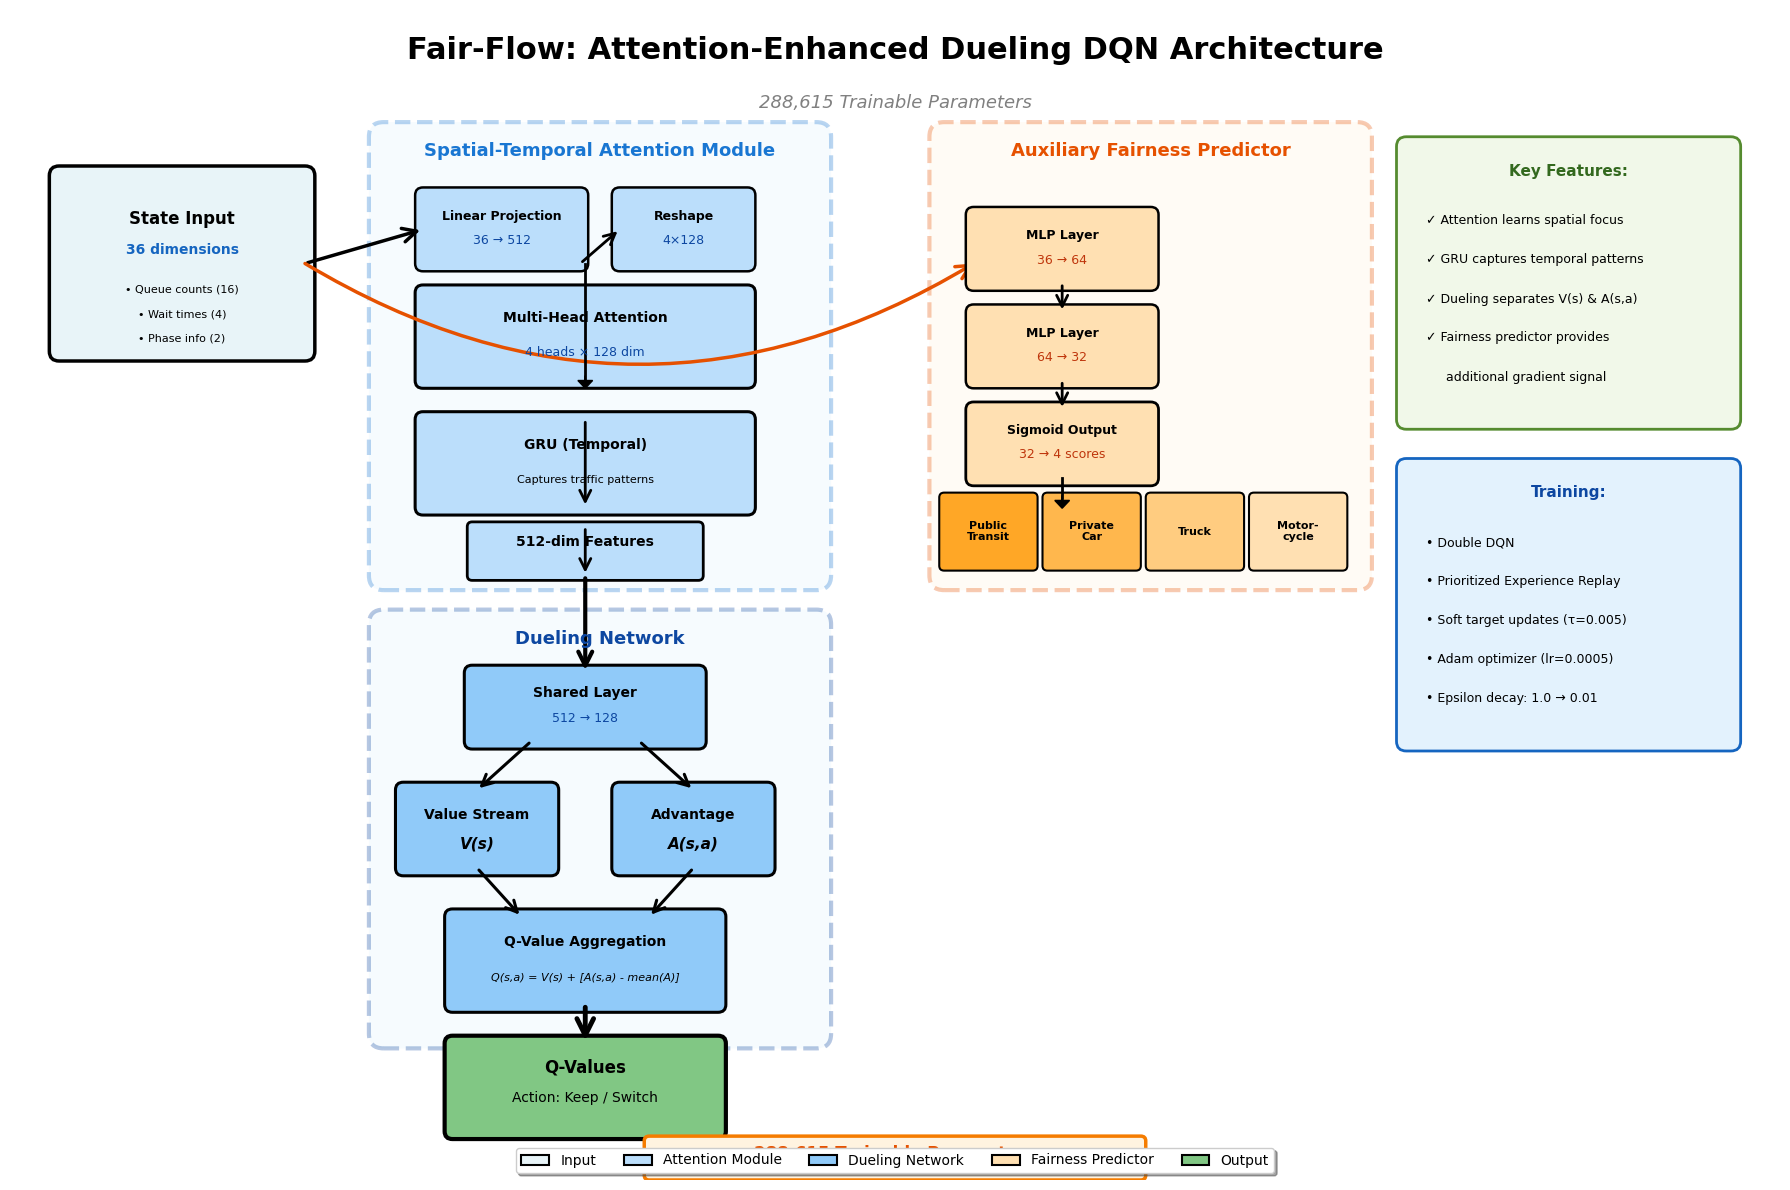

✅ Improved architecture diagram created successfully!
📁 Saved as 'fairflow_architecture_improved.png'

🔧 Key improvements:
   • Better arrow alignment and flow
   • Clearer text positioning
   • Improved spacing between components
   • More logical visual hierarchy
   • Better color coordination


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, ConnectionPatch
import matplotlib.lines as mlines

# Create figure with better spacing
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 12)
ax.axis('off')

# Title
ax.text(9, 11.5, 'Fair-Flow: Attention-Enhanced Dueling DQN Architecture',
        fontsize=22, fontweight='bold', ha='center')
ax.text(9, 11, '288,615 Trainable Parameters',
        fontsize=13, ha='center', style='italic', color='gray')

# Color scheme
color_input = '#E8F4F8'
color_attention = '#BBDEFB'
color_dueling = '#90CAF9'
color_fairness = '#FFE0B2'
color_output = '#81C784'

# ==================== INPUT STATE ====================
input_box = FancyBboxPatch((0.5, 8.5), 2.5, 1.8, boxstyle="round,pad=0.1",
                           edgecolor='black', facecolor=color_input, linewidth=2.5)
ax.add_patch(input_box)
ax.text(1.75, 9.8, 'State Input', fontsize=12, fontweight='bold', ha='center')
ax.text(1.75, 9.5, '36 dimensions', fontsize=10, ha='center', fontweight='bold', color='#1565C0')
ax.text(1.75, 9.1, '• Queue counts (16)', fontsize=8, ha='center')
ax.text(1.75, 8.85, '• Wait times (4)', fontsize=8, ha='center')
ax.text(1.75, 8.6, '• Phase info (2)', fontsize=8, ha='center')

# ==================== SPATIAL-TEMPORAL ATTENTION MODULE ====================
# Background box
attention_bg = FancyBboxPatch((3.8, 6.2), 4.4, 4.5, boxstyle="round,pad=0.15",
                              edgecolor='#1976D2', facecolor='#E3F2FD',
                              linewidth=3, linestyle='--', alpha=0.3)
ax.add_patch(attention_bg)
ax.text(6, 10.5, 'Spatial-Temporal Attention Module',
        fontsize=13, fontweight='bold', ha='center', color='#1976D2')

# Linear Projection
proj_box = FancyBboxPatch((4.2, 9.4), 1.6, 0.7, boxstyle="round,pad=0.08",
                          edgecolor='black', facecolor=color_attention, linewidth=1.8)
ax.add_patch(proj_box)
ax.text(5, 9.85, 'Linear Projection', fontsize=9, fontweight='bold', ha='center')
ax.text(5, 9.6, '36 → 512', fontsize=9, ha='center', color='#0D47A1')

# Reshape
reshape_box = FancyBboxPatch((6.2, 9.4), 1.3, 0.7, boxstyle="round,pad=0.08",
                             edgecolor='black', facecolor=color_attention, linewidth=1.8)
ax.add_patch(reshape_box)
ax.text(6.85, 9.85, 'Reshape', fontsize=9, fontweight='bold', ha='center')
ax.text(6.85, 9.6, '4×128', fontsize=9, ha='center', color='#0D47A1')

# Multi-head Attention
attn_box = FancyBboxPatch((4.2, 8.2), 3.3, 0.9, boxstyle="round,pad=0.08",
                          edgecolor='black', facecolor=color_attention, linewidth=2.2)
ax.add_patch(attn_box)
ax.text(5.85, 8.8, 'Multi-Head Attention', fontsize=10, fontweight='bold', ha='center')
ax.text(5.85, 8.45, '4 heads × 128 dim', fontsize=9, ha='center', color='#0D47A1')

# GRU Layer
gru_box = FancyBboxPatch((4.2, 6.9), 3.3, 0.9, boxstyle="round,pad=0.08",
                         edgecolor='black', facecolor=color_attention, linewidth=2.2)
ax.add_patch(gru_box)
ax.text(5.85, 7.5, 'GRU (Temporal)', fontsize=10, fontweight='bold', ha='center')
ax.text(5.85, 7.15, 'Captures traffic patterns', fontsize=8, ha='center')

# Features output
features_box = FancyBboxPatch((4.7, 6.2), 2.3, 0.5, boxstyle="round,pad=0.05",
                              edgecolor='black', facecolor=color_attention, linewidth=2)
ax.add_patch(features_box)
ax.text(5.85, 6.5, '512-dim Features', fontsize=10, fontweight='bold', ha='center')

# Arrows within attention module
arrow1 = FancyArrowPatch((3, 9.4), (4.2, 9.75),
                        arrowstyle='->', mutation_scale=25, lw=2.5, color='black')
ax.add_patch(arrow1)

arrow2 = FancyArrowPatch((5.8, 9.4), (6.2, 9.75),
                        arrowstyle='->', mutation_scale=20, lw=2, color='black')
ax.add_patch(arrow2)

arrow3 = FancyArrowPatch((5.85, 9.1), (5.85, 9.1),
                        arrowstyle='->', mutation_scale=20, lw=2, color='black')
ax.plot([5.85, 5.85], [9.4, 8.2], 'k-', lw=2)
ax.arrow(5.85, 8.25, 0, -0.05, head_width=0.15, head_length=0.08, fc='black', ec='black')

arrow4 = FancyArrowPatch((5.85, 7.8), (5.85, 6.9),
                        arrowstyle='->', mutation_scale=20, lw=2, color='black')
ax.add_patch(arrow4)

arrow5 = FancyArrowPatch((5.85, 6.7), (5.85, 6.2),
                        arrowstyle='->', mutation_scale=20, lw=2, color='black')
ax.add_patch(arrow5)

# ==================== DUELING NETWORK ====================
# Background box
dueling_bg = FancyBboxPatch((3.8, 1.5), 4.4, 4.2, boxstyle="round,pad=0.15",
                            edgecolor='#0D47A1', facecolor='#E3F2FD',
                            linewidth=3, linestyle='--', alpha=0.3)
ax.add_patch(dueling_bg)
ax.text(6, 5.5, 'Dueling Network',
        fontsize=13, fontweight='bold', ha='center', color='#0D47A1')

# Shared layer
shared_box = FancyBboxPatch((4.7, 4.5), 2.3, 0.7, boxstyle="round,pad=0.08",
                            edgecolor='black', facecolor=color_dueling, linewidth=2.2)
ax.add_patch(shared_box)
ax.text(5.85, 4.95, 'Shared Layer', fontsize=10, fontweight='bold', ha='center')
ax.text(5.85, 4.7, '512 → 128', fontsize=9, ha='center', color='#0D47A1')

# Arrow from attention to shared
arrow6 = FancyArrowPatch((5.85, 6.2), (5.85, 5.2),
                        arrowstyle='->', mutation_scale=25, lw=3, color='black')
ax.add_patch(arrow6)

# Value stream
value_box = FancyBboxPatch((4, 3.2), 1.5, 0.8, boxstyle="round,pad=0.08",
                           edgecolor='black', facecolor=color_dueling, linewidth=2.2)
ax.add_patch(value_box)
ax.text(4.75, 3.7, 'Value Stream', fontsize=10, fontweight='bold', ha='center')
ax.text(4.75, 3.4, 'V(s)', fontsize=11, ha='center', style='italic', fontweight='bold')

# Advantage stream
adv_box = FancyBboxPatch((6.2, 3.2), 1.5, 0.8, boxstyle="round,pad=0.08",
                         edgecolor='black', facecolor=color_dueling, linewidth=2.2)
ax.add_patch(adv_box)
ax.text(6.95, 3.7, 'Advantage', fontsize=10, fontweight='bold', ha='center')
ax.text(6.95, 3.4, 'A(s,a)', fontsize=11, ha='center', style='italic', fontweight='bold')

# Arrows to streams
arrow7 = FancyArrowPatch((5.3, 4.5), (4.75, 4.0),
                        arrowstyle='->', mutation_scale=20, lw=2.2, color='black')
ax.add_patch(arrow7)

arrow8 = FancyArrowPatch((6.4, 4.5), (6.95, 4.0),
                        arrowstyle='->', mutation_scale=20, lw=2.2, color='black')
ax.add_patch(arrow8)

# Aggregation box
agg_box = FancyBboxPatch((4.5, 1.8), 2.7, 0.9, boxstyle="round,pad=0.08",
                         edgecolor='black', facecolor=color_dueling, linewidth=2.2)
ax.add_patch(agg_box)
ax.text(5.85, 2.4, 'Q-Value Aggregation', fontsize=10, fontweight='bold', ha='center')
ax.text(5.85, 2.05, 'Q(s,a) = V(s) + [A(s,a) - mean(A)]', fontsize=8, ha='center', style='italic')

# Arrows to aggregation
arrow9 = FancyArrowPatch((4.75, 3.2), (5.2, 2.7),
                        arrowstyle='->', mutation_scale=20, lw=2.2, color='black')
ax.add_patch(arrow9)

arrow10 = FancyArrowPatch((6.95, 3.2), (6.5, 2.7),
                         arrowstyle='->', mutation_scale=20, lw=2.2, color='black')
ax.add_patch(arrow10)

# ==================== AUXILIARY FAIRNESS PREDICTOR ====================
# Background box
fairness_bg = FancyBboxPatch((9.5, 6.2), 4.2, 4.5, boxstyle="round,pad=0.15",
                             edgecolor='#E65100', facecolor='#FFF3E0',
                             linewidth=3, linestyle='--', alpha=0.3)
ax.add_patch(fairness_bg)
ax.text(11.6, 10.5, 'Auxiliary Fairness Predictor',
        fontsize=13, fontweight='bold', ha='center', color='#E65100')

# Arrow from input to fairness (curved)
arrow_fair = ConnectionPatch((3, 9.4), (9.8, 9.4), "data", "data",
                              arrowstyle='->', shrinkA=0, shrinkB=0, mutation_scale=25,
                              lw=2.5, color='#E65100',
                              connectionstyle="arc3,rad=.3")
ax.add_artist(arrow_fair)

# MLP Layer 1
mlp1_box = FancyBboxPatch((9.8, 9.2), 1.8, 0.7, boxstyle="round,pad=0.08",
                          edgecolor='black', facecolor=color_fairness, linewidth=1.8)
ax.add_patch(mlp1_box)
ax.text(10.7, 9.65, 'MLP Layer', fontsize=9, fontweight='bold', ha='center')
ax.text(10.7, 9.4, '36 → 64', fontsize=9, ha='center', color='#BF360C')

# MLP Layer 2
mlp2_box = FancyBboxPatch((9.8, 8.2), 1.8, 0.7, boxstyle="round,pad=0.08",
                          edgecolor='black', facecolor=color_fairness, linewidth=1.8)
ax.add_patch(mlp2_box)
ax.text(10.7, 8.65, 'MLP Layer', fontsize=9, fontweight='bold', ha='center')
ax.text(10.7, 8.4, '64 → 32', fontsize=9, ha='center', color='#BF360C')

# Sigmoid Output
sigmoid_box = FancyBboxPatch((9.8, 7.2), 1.8, 0.7, boxstyle="round,pad=0.08",
                             edgecolor='black', facecolor=color_fairness, linewidth=2)
ax.add_patch(sigmoid_box)
ax.text(10.7, 7.65, 'Sigmoid Output', fontsize=9, fontweight='bold', ha='center')
ax.text(10.7, 7.4, '32 → 4 scores', fontsize=9, ha='center', color='#BF360C')

# Arrows between MLP layers
arrow11 = FancyArrowPatch((10.7, 9.2), (10.7, 8.9),
                         arrowstyle='->', mutation_scale=20, lw=2, color='black')
ax.add_patch(arrow11)

arrow12 = FancyArrowPatch((10.7, 8.2), (10.7, 7.9),
                         arrowstyle='->', mutation_scale=20, lw=2, color='black')
ax.add_patch(arrow12)

# Vehicle type outputs
vehicle_types = ['Public\nTransit', 'Private\nCar', 'Truck', 'Motor-\ncycle']
vehicle_colors = ['#FFA726', '#FFB74D', '#FFCC80', '#FFE0B2']

for i, (vtype, vcolor) in enumerate(zip(vehicle_types, vehicle_colors)):
    vbox = FancyBboxPatch((9.5 + i*1.05, 6.3), 0.9, 0.7,
                          boxstyle="round,pad=0.05",
                          edgecolor='black', facecolor=vcolor, linewidth=1.5)
    ax.add_patch(vbox)
    ax.text(9.95 + i*1.05, 6.65, vtype, fontsize=8, ha='center', va='center', fontweight='bold')

# Arrow to vehicle outputs
ax.plot([10.7, 10.7], [7.2, 7.0], 'k-', lw=2)
ax.arrow(10.7, 7.02, 0, -0.05, head_width=0.15, head_length=0.08, fc='black', ec='black')

# ==================== OUTPUT ====================
output_box = FancyBboxPatch((4.5, 0.5), 2.7, 0.9, boxstyle="round,pad=0.08",
                            edgecolor='black', facecolor=color_output, linewidth=3)
ax.add_patch(output_box)
ax.text(5.85, 1.1, 'Q-Values', fontsize=12, fontweight='bold', ha='center')
ax.text(5.85, 0.8, 'Action: Keep / Switch', fontsize=10, ha='center')

# Arrow to output
arrow13 = FancyArrowPatch((5.85, 1.8), (5.85, 1.4),
                         arrowstyle='->', mutation_scale=30, lw=3.5, color='black')
ax.add_patch(arrow13)

# ==================== INFO BOXES ====================
# Key Features
features_info = FancyBboxPatch((14.2, 7.8), 3.3, 2.8, boxstyle="round,pad=0.1",
                               edgecolor='#558B2F', facecolor='#F1F8E9', linewidth=2)
ax.add_patch(features_info)
ax.text(15.85, 10.3, 'Key Features:', fontsize=11, fontweight='bold', ha='center', color='#33691E')
ax.text(14.4, 9.8, '✓ Attention learns spatial focus', fontsize=9, ha='left')
ax.text(14.4, 9.4, '✓ GRU captures temporal patterns', fontsize=9, ha='left')
ax.text(14.4, 9.0, '✓ Dueling separates V(s) & A(s,a)', fontsize=9, ha='left')
ax.text(14.4, 8.6, '✓ Fairness predictor provides', fontsize=9, ha='left')
ax.text(14.6, 8.2, 'additional gradient signal', fontsize=9, ha='left')

# Training Info
training_info = FancyBboxPatch((14.2, 4.5), 3.3, 2.8, boxstyle="round,pad=0.1",
                               edgecolor='#1565C0', facecolor='#E3F2FD', linewidth=2)
ax.add_patch(training_info)
ax.text(15.85, 7, 'Training:', fontsize=11, fontweight='bold', ha='center', color='#0D47A1')
ax.text(14.4, 6.5, '• Double DQN', fontsize=9, ha='left')
ax.text(14.4, 6.1, '• Prioritized Experience Replay', fontsize=9, ha='left')
ax.text(14.4, 5.7, '• Soft target updates (τ=0.005)', fontsize=9, ha='left')
ax.text(14.4, 5.3, '• Adam optimizer (lr=0.0005)', fontsize=9, ha='left')
ax.text(14.4, 4.9, '• Epsilon decay: 1.0 → 0.01', fontsize=9, ha='left')

# Legend
legend_elements = [
    mpatches.Patch(facecolor=color_input, edgecolor='black', linewidth=1.5, label='Input'),
    mpatches.Patch(facecolor=color_attention, edgecolor='black', linewidth=1.5, label='Attention Module'),
    mpatches.Patch(facecolor=color_dueling, edgecolor='black', linewidth=1.5, label='Dueling Network'),
    mpatches.Patch(facecolor=color_fairness, edgecolor='black', linewidth=1.5, label='Fairness Predictor'),
    mpatches.Patch(facecolor=color_output, edgecolor='black', linewidth=1.5, label='Output')
]
ax.legend(handles=legend_elements, loc='lower center', fontsize=10, ncol=5,
         frameon=True, fancybox=True, shadow=True)

# Total Parameters highlight
param_box = FancyBboxPatch((6.5, 0.05), 5, 0.35, boxstyle="round,pad=0.05",
                           edgecolor='#F57C00', facecolor='#FFF3E0', linewidth=2.5)
ax.add_patch(param_box)
ax.text(9, 0.22, '288,615 Trainable Parameters',
        fontsize=12, ha='center', fontweight='bold', color='#E65100')

plt.tight_layout()
plt.savefig('fairflow_architecture_improved.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Improved architecture diagram created successfully!")
print("📁 Saved as 'fairflow_architecture_improved.png'")
print("\n🔧 Key improvements:")
print("   • Better arrow alignment and flow")
print("   • Clearer text positioning")
print("   • Improved spacing between components")
print("   • More logical visual hierarchy")
print("   • Better color coordination")

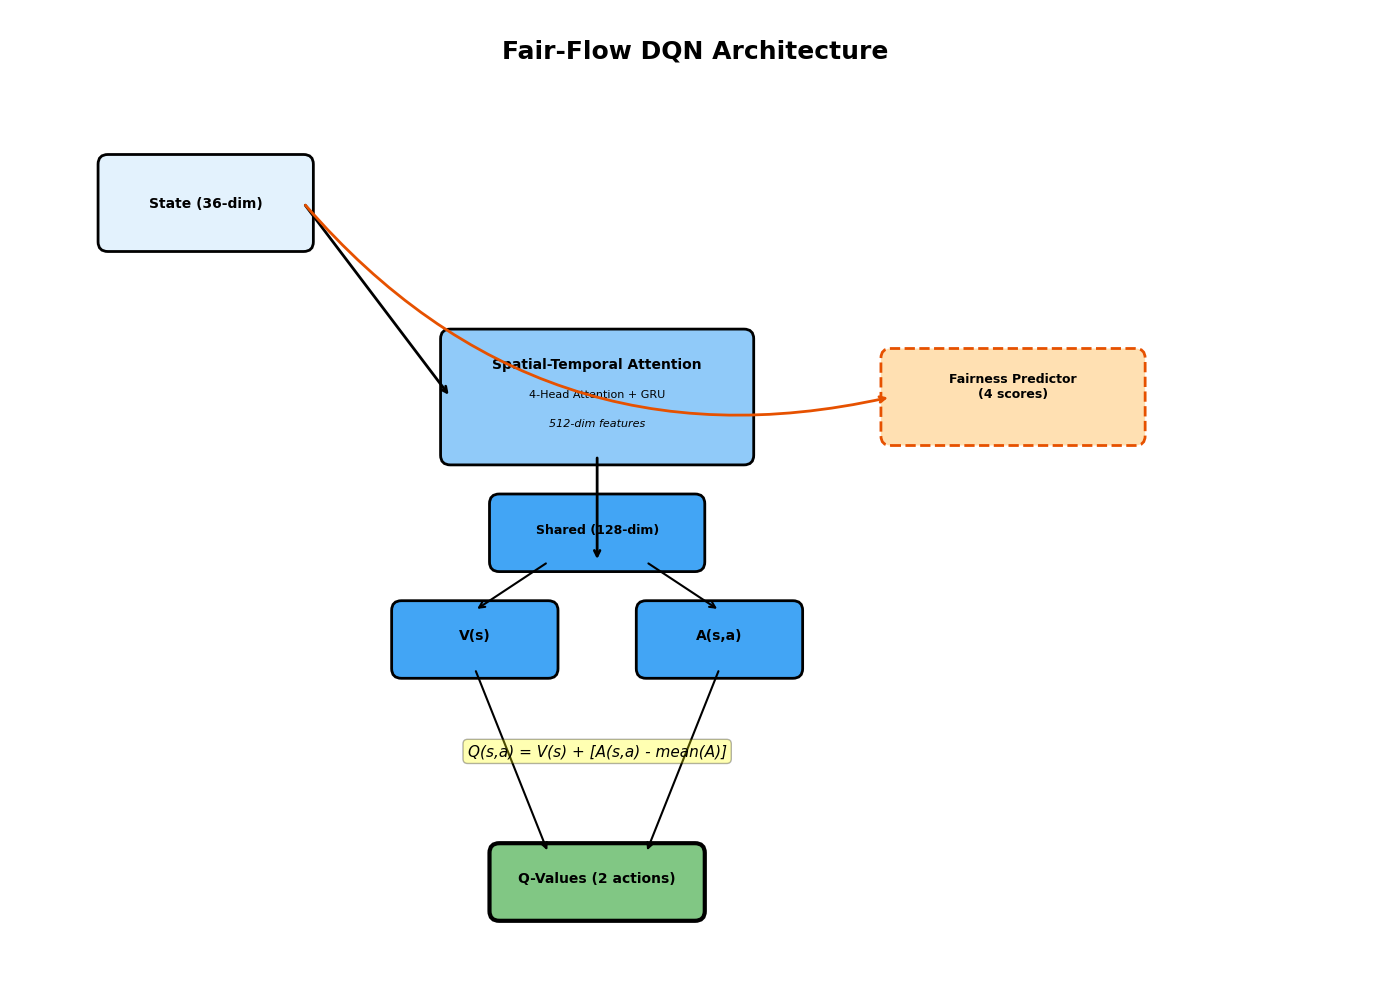

✅ Simple architecture diagram created!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrow
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(7, 9.5, 'Fair-Flow DQN Architecture', fontsize=18, fontweight='bold', ha='center')

# Define positions
y_input = 8
y_attention = 6
y_dueling = 3.5
y_output = 1

# Colors
c1 = '#E3F2FD'
c2 = '#90CAF9'
c3 = '#42A5F5'
c4 = '#81C784'

# INPUT
rect1 = FancyBboxPatch((1, y_input-0.4), 2, 0.8, boxstyle="round,pad=0.1",
                       edgecolor='black', facecolor=c1, linewidth=2)
ax.add_patch(rect1)
ax.text(2, y_input, 'State (36-dim)', fontsize=10, ha='center', va='center', fontweight='bold')

# ATTENTION MODULE
rect2 = FancyBboxPatch((4.5, y_attention-0.6), 3, 1.2, boxstyle="round,pad=0.1",
                       edgecolor='black', facecolor=c2, linewidth=2)
ax.add_patch(rect2)
ax.text(6, y_attention+0.3, 'Spatial-Temporal Attention', fontsize=10, ha='center', fontweight='bold')
ax.text(6, y_attention, '4-Head Attention + GRU', fontsize=8, ha='center')
ax.text(6, y_attention-0.3, '512-dim features', fontsize=8, ha='center', style='italic')

# Arrow
ax.annotate('', xy=(4.5, y_attention), xytext=(3, y_input),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# DUELING NETWORK
# Shared
rect3 = FancyBboxPatch((5, y_dueling+0.8), 2, 0.6, boxstyle="round,pad=0.1",
                       edgecolor='black', facecolor=c3, linewidth=2)
ax.add_patch(rect3)
ax.text(6, y_dueling+1.1, 'Shared (128-dim)', fontsize=9, ha='center', fontweight='bold')

ax.annotate('', xy=(6, y_dueling+0.8), xytext=(6, y_attention-0.6),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Value
rect4 = FancyBboxPatch((4, y_dueling-0.3), 1.5, 0.6, boxstyle="round,pad=0.1",
                       edgecolor='black', facecolor=c3, linewidth=2)
ax.add_patch(rect4)
ax.text(4.75, y_dueling, 'V(s)', fontsize=10, ha='center', fontweight='bold')

# Advantage
rect5 = FancyBboxPatch((6.5, y_dueling-0.3), 1.5, 0.6, boxstyle="round,pad=0.1",
                       edgecolor='black', facecolor=c3, linewidth=2)
ax.add_patch(rect5)
ax.text(7.25, y_dueling, 'A(s,a)', fontsize=10, ha='center', fontweight='bold')

# Arrows
ax.annotate('', xy=(4.75, y_dueling+0.3), xytext=(5.5, y_dueling+0.8),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
ax.annotate('', xy=(7.25, y_dueling+0.3), xytext=(6.5, y_dueling+0.8),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

# Q-values
rect6 = FancyBboxPatch((5, y_output-0.3), 2, 0.6, boxstyle="round,pad=0.1",
                       edgecolor='black', facecolor=c4, linewidth=3)
ax.add_patch(rect6)
ax.text(6, y_output, 'Q-Values (2 actions)', fontsize=10, ha='center', fontweight='bold')

# Arrows to Q
ax.annotate('', xy=(5.5, y_output+0.3), xytext=(4.75, y_dueling-0.3),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
ax.annotate('', xy=(6.5, y_output+0.3), xytext=(7.25, y_dueling-0.3),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

# FAIRNESS BRANCH
rect7 = FancyBboxPatch((9, y_attention-0.4), 2.5, 0.8, boxstyle="round,pad=0.1",
                       edgecolor='#E65100', facecolor='#FFE0B2', linewidth=2, linestyle='--')
ax.add_patch(rect7)
ax.text(10.25, y_attention, 'Fairness Predictor\n(4 scores)', fontsize=9, ha='center', fontweight='bold')

ax.annotate('', xy=(9, y_attention), xytext=(3, y_input),
            arrowprops=dict(arrowstyle='->', lw=2, color='#E65100',
                          connectionstyle="arc3,rad=0.3"))

# Formula
ax.text(6, 2.3, r'Q(s,a) = V(s) + [A(s,a) - mean(A)]',
        fontsize=11, ha='center', style='italic',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('fairflow_architecture_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Simple architecture diagram created!")

In [ ]:
!pip install torchviz graphviz

In [ ]:
# Cell 4: Fair-Flow Two-Objective Training Function (Throughput vs Fairness)
import time
from datetime import datetime
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

def train_fairflow_agent(
    episodes=500,
    verbose=True,
    save_models=True,
    checkpoint_freq=50,
    early_stopping_patience=100,
    use_temporal=True
):
    """
    Training function for Fair-Flow: Two-Objective Throughput-Fairness Tradeoff

    Args:
        episodes: Number of training episodes
        verbose: Print detailed progress
        save_models: Save checkpoints and final model
        checkpoint_freq: Episodes between detailed reports
        early_stopping_patience: Stop if no improvement for N episodes
        use_temporal: Use temporal features in state
    """
    # Initialize environment and agent
    config = Config()
    config.use_temporal_features = use_temporal
    env = FairFlowTrafficEnvironment(config)

    state_size = 36 if use_temporal else 26
    agent = FairFlowAgent(state_size=state_size, action_size=2, config=config)

    # Enhanced tracking metrics
    episode_rewards = []
    episode_losses = []
    vehicle_type_metrics = {
        vt: {'served': [], 'wait_times': [], 'service_times': []}
        for vt in VehicleType
    }

    # Fairness tracking
    jains_index_history = []
    gini_coefficient_history = []
    fairness_per_type = {vt: [] for vt in VehicleType}

    # Temporal tracking (if enabled)
    hourly_performance = {h: [] for h in range(24)} if use_temporal else None

    # Reward components (two objectives only)
    reward_components = {
        'throughput': [],
        'fairness': [],
        'wait_penalty': []
    }

    # Performance tracking
    best_reward = float('-inf')
    best_fairness = 0.0
    no_improvement_count = 0
    recent_rewards = deque(maxlen=100)

    # Two-objective Pareto front (efficiency vs fairness)
    pareto_front = []

    print("=" * 80)
    print("🚦 Training Fair-Flow: Two-Objective Throughput-Fairness Tradeoff")
    print("=" * 80)
    print(f"🎯 Two Objectives: Throughput (45%) + Fairness (50%)")
    print(f"🚗 Vehicle Types: {len(VehicleType)} (No special priority)")
    print(f"📊 State Space: {state_size} dimensions")
    print(f"🎮 Action Space: 2 actions (Keep/Switch)")
    print(f"🧠 Network Parameters: {sum(p.numel() for p in agent.q_network.parameters()):,}")
    print(f"⏰ Temporal Features: {'Enabled' if use_temporal else 'Disabled'}")
    print(f"💾 Device: {device}")
    print("=" * 80)

    training_start_time = time.time()

    for episode in range(episodes):
        state, _ = env.reset()
        episode_reward = 0
        episode_losses_list = []
        vehicles_served_by_type = {vt: 0 for vt in VehicleType}
        episode_reward_breakdown = {
            'throughput': 0,
            'fairness': 0,
            'wait_penalty': 0
        }

        # Episode variables
        steps = 0

        while True:
            # Get action
            action = agent.act(state, training=True)

            # Environment step
            next_state, reward, done, _, info = env.step(action)

            # Store experience
            agent.remember(state, action, reward, next_state, done, info)

            # Train agent
            loss = agent.replay()
            if loss is not None:
                episode_losses_list.append(loss)

            # Update tracking
            episode_reward += reward
            steps += 1

            # Track vehicles served by type
            for vt in VehicleType:
                vehicles_served_by_type[vt] += info['vehicles_served'].get(vt, 0)

            # Approximate reward breakdown (based on weights)
            episode_reward_breakdown['throughput'] += reward * config.throughput_weight
            episode_reward_breakdown['fairness'] += reward * config.fairness_weight
            episode_reward_breakdown['wait_penalty'] += reward * config.wait_penalty_weight

            state = next_state

            if done:
                break

        # Record episode metrics
        episode_rewards.append(episode_reward)
        recent_rewards.append(episode_reward)

        # Fairness metrics
        jains_index = info.get('jains_index', 0.0)
        jains_index_history.append(jains_index)
        agent.jains_index_history.append(jains_index)

        # Calculate Gini coefficient from wait times
        all_wait_times = []
        for vt in VehicleType:
            if env.wait_time_by_type[vt]:
                all_wait_times.extend(env.wait_time_by_type[vt])

        if all_wait_times:
            gini = calculate_gini_coefficient(all_wait_times)
            gini_coefficient_history.append(gini)

        # Update vehicle type metrics
        for vt in VehicleType:
            vehicle_type_metrics[vt]['served'].append(vehicles_served_by_type[vt])

            # Average wait times for this episode
            if env.wait_time_by_type[vt]:
                avg_wait = np.mean(env.wait_time_by_type[vt])
                vehicle_type_metrics[vt]['wait_times'].append(avg_wait)
                fairness_per_type[vt].append(avg_wait)

        # Track reward components
        for key in reward_components:
            reward_components[key].append(episode_reward_breakdown[key])

        # Track hourly performance (if temporal enabled)
        if use_temporal and hourly_performance is not None:
            hour = info.get('current_hour', 8)
            hourly_performance[hour].append(episode_reward)

        # Update Pareto front (two objectives: efficiency vs fairness)
        efficiency = sum(vehicles_served_by_type.values()) / max(steps, 1)
        fairness_score = jains_index

        pareto_point = (efficiency, fairness_score)
        pareto_front.append(pareto_point)

        # Check for best performance
        improvement = False
        if episode_reward > best_reward:
            best_reward = episode_reward
            improvement = True

        if jains_index > best_fairness:
            best_fairness = jains_index
            improvement = True

        if improvement:
            no_improvement_count = 0
            if save_models:
                torch.save({
                    'episode': episode,
                    'model_state_dict': agent.q_network.state_dict(),
                    'optimizer_state_dict': agent.optimizer.state_dict(),
                    'reward': best_reward,
                    'fairness': best_fairness,
                    'config': config
                }, f'best_fairflow_model_ep{episode}.pth')
        else:
            no_improvement_count += 1

        # Verbose output
        if verbose and (episode % 10 == 0 or episode < 10):
            avg_recent = np.mean(list(recent_rewards)[-20:]) if len(recent_rewards) >= 20 else np.mean(list(recent_rewards))
            avg_loss = np.mean(episode_losses_list) if episode_losses_list else 0
            stats = agent.get_advanced_stats()

            print(f"Episode {episode:4d} | "
                  f"Reward: {episode_reward:7.2f} | "
                  f"Avg20: {avg_recent:7.2f} | "
                  f"ε: {stats['epsilon']:.3f} | "
                  f"Jain's: {jains_index:.3f} | "
                  f"Cars: {sum(vehicles_served_by_type.values()):3d} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"LR: {stats['learning_rate']:.5f}")

        # Detailed milestone reporting
        if episode > 0 and episode % checkpoint_freq == 0:
            print(f"\n{'='*80}")
            print(f"📊 Checkpoint at Episode {episode}")
            print(f"{'='*80}")

            # Performance metrics
            recent_50 = episode_rewards[-50:]
            print(f"\n🎯 Performance Metrics:")
            print(f"   Last 50 episodes - Avg: {np.mean(recent_50):.2f}, Best: {max(recent_50):.2f}")
            print(f"   Best overall reward: {best_reward:.2f}")
            print(f"   Best Jain's fairness: {best_fairness:.3f}")

            # Fairness metrics
            if len(jains_index_history) >= 50:
                recent_jains = jains_index_history[-50:]
                print(f"\n⚖️  Fairness Metrics (Last 50 Episodes):")
                print(f"   Avg Jain's Index: {np.mean(recent_jains):.3f} (Target: {config.target_jain_index})")
                print(f"   Best Jain's Index: {max(recent_jains):.3f}")

                if gini_coefficient_history:
                    recent_gini = gini_coefficient_history[-50:]
                    print(f"   Avg Gini Coefficient: {np.mean(recent_gini):.3f} (Lower is more fair)")

            # Vehicle type breakdown with fairness
            print(f"\n🚗 Vehicles Served (last 50 episodes avg):")
            for vt in VehicleType:
                recent_served = vehicle_type_metrics[vt]['served'][-50:]
                if recent_served:
                    avg_served = np.mean(recent_served)
                    print(f"   {vt.name:15s}: {avg_served:6.2f} per episode", end="")

                    # Show average wait time
                    if vehicle_type_metrics[vt]['wait_times']:
                        recent_waits = vehicle_type_metrics[vt]['wait_times'][-50:]
                        if recent_waits:
                            avg_wait = np.mean(recent_waits)
                            print(f" (Avg wait: {avg_wait:.1f} steps)")
                    else:
                        print()

            # Learning progress
            if episode >= 100:
                early_avg = np.mean(episode_rewards[50:100])
                recent_avg = np.mean(episode_rewards[-50:])
                improvement_pct = ((recent_avg - early_avg) / abs(early_avg)) * 100 if early_avg != 0 else 0

                print(f"\n📈 Learning Progress:")
                print(f"   Improvement: {improvement_pct:+.1f}% (recent vs early)")

                if improvement_pct > 20:
                    print("   🚀 Excellent learning progress!")
                elif improvement_pct > 10:
                    print("   ✅ Good learning detected")
                elif improvement_pct > 0:
                    print("   🟨 Mild improvement")
                else:
                    print("   ⚠️ No significant improvement")

            # Two-objective status
            print(f"\n🎯 Two-Objective Status:")
            recent_efficiency = np.mean([p[0] for p in pareto_front[-50:]])
            recent_fairness = np.mean([p[1] for p in pareto_front[-50:]])
            print(f"   Throughput: {recent_efficiency:.3f} vehicles/step")
            print(f"   Fairness: {recent_fairness:.3f} (Jain's Index)")

            # Agent statistics
            stats = agent.get_advanced_stats()
            print(f"\n🧠 Agent Statistics:")
            print(f"   Epsilon: {stats['epsilon']:.4f}")
            print(f"   Beta (IS weight): {stats['beta']:.4f}")
            print(f"   Memory size: {stats['memory_size']:,}")
            print(f"   Learning rate: {stats['learning_rate']:.6f}")
            print(f"   Avg TD error: {stats.get('avg_td_error', 0):.4f}")

            print(f"{'='*80}\n")

            # Save checkpoint
            if save_models:
                torch.save({
                    'episode': episode,
                    'model_state_dict': agent.q_network.state_dict(),
                    'optimizer_state_dict': agent.optimizer.state_dict(),
                    'rewards': episode_rewards,
                    'jains_index': jains_index_history,
                    'vehicle_metrics': vehicle_type_metrics,
                    'config': config
                }, f'checkpoint_fairflow_ep{episode}.pth')

    # Training completed
    total_time = time.time() - training_start_time
    print(f"\n{'='*80}")
    print(f"🎉 TRAINING COMPLETED!")
    print(f"{'='*80}")
    print(f"⏱️  Total time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
    print(f"📊 Total episodes: {len(episode_rewards)}")
    print(f"🏆 Best reward achieved: {best_reward:.2f}")
    print(f"⚖️  Best fairness achieved: {best_fairness:.3f}")

    # Final analysis
    if len(episode_rewards) >= 100:
        first_100 = np.mean(episode_rewards[:100])
        last_100 = np.mean(episode_rewards[-100:])
        improvement = last_100 - first_100
        improvement_pct = (improvement / abs(first_100)) * 100 if first_100 != 0 else 0

        print(f"\n📊 LEARNING ANALYSIS:")
        print(f"   First 100 episodes avg: {first_100:.2f}")
        print(f"   Last 100 episodes avg: {last_100:.2f}")
        print(f"   Total improvement: {improvement:+.2f} ({improvement_pct:+.1f}%)")

        # Fairness analysis
        if len(jains_index_history) >= 100:
            early_fairness = np.mean(jains_index_history[:100])
            recent_fairness = np.mean(jains_index_history[-100:])
            fairness_improvement = recent_fairness - early_fairness

            print(f"\n⚖️  FAIRNESS ANALYSIS:")
            print(f"   Early avg Jain's Index: {early_fairness:.3f}")
            print(f"   Recent avg Jain's Index: {recent_fairness:.3f}")
            print(f"   Improvement: {fairness_improvement:+.3f}")

            if recent_fairness >= config.target_jain_index:
                print(f"   ✅ TARGET FAIRNESS ACHIEVED!")
            else:
                gap = config.target_jain_index - recent_fairness
                print(f"   📊 Gap to target: {gap:.3f}")

    # Save final model
    if save_models:
        torch.save({
            'model_state_dict': agent.q_network.state_dict(),
            'optimizer_state_dict': agent.optimizer.state_dict(),
            'final_reward': episode_rewards[-1],
            'best_reward': best_reward,
            'best_fairness': best_fairness,
            'config': config,
            'training_history': {
                'rewards': episode_rewards,
                'jains_index': jains_index_history,
                'gini_coefficient': gini_coefficient_history,
                'vehicle_metrics': vehicle_type_metrics,
                'reward_components': reward_components,
                'hourly_performance': hourly_performance
            }
        }, 'final_fairflow_traffic_model.pth')
        print(f"\n💾 Final model saved to 'final_fairflow_traffic_model.pth'")

    return {
        'agent': agent,
        'rewards': episode_rewards,
        'losses': agent.losses,
        'jains_index': jains_index_history,
        'gini_coefficient': gini_coefficient_history,
        'vehicle_metrics': vehicle_type_metrics,
        'reward_components': reward_components,
        'pareto_front': pareto_front,
        'fairness_per_type': fairness_per_type,
        'hourly_performance': hourly_performance,
        'best_reward': best_reward,
        'best_fairness': best_fairness,
        'training_time': total_time
    }

def plot_fairflow_results(results):
    """Comprehensive visualization for Fair-Flow two-objective training results"""

    # Create figure with custom layout
    fig = plt.figure(figsize=(20, 12))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

    # Title
    fig.suptitle('Fair-Flow: Two-Objective Throughput-Fairness Tradeoff - Training Results',
                 fontsize=16, fontweight='bold')

    # 1. Learning curve with confidence interval
    ax1 = fig.add_subplot(gs[0, :2])
    rewards = results['rewards']
    episodes = list(range(len(rewards)))

    window = 50
    moving_avg = []
    moving_std = []
    for i in range(len(rewards)):
        start_idx = max(0, i - window + 1)
        window_data = rewards[start_idx:i+1]
        moving_avg.append(np.mean(window_data))
        moving_std.append(np.std(window_data))

    moving_avg = np.array(moving_avg)
    moving_std = np.array(moving_std)

    ax1.plot(episodes, rewards, alpha=0.3, color='blue', label='Episode Reward')
    ax1.plot(episodes, moving_avg, 'b-', linewidth=2, label=f'Moving Avg ({window})')
    ax1.fill_between(episodes, moving_avg - moving_std, moving_avg + moving_std,
                      alpha=0.2, color='blue', label='±1 Std Dev')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Total Reward')
    ax1.set_title('Learning Progress with Confidence Interval')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Fairness Evolution (Jain's Index)
    ax2 = fig.add_subplot(gs[0, 2])
    if results['jains_index']:
        jains = results['jains_index']
        ax2.plot(jains, 'green', alpha=0.6, label="Jain's Index")

        # Moving average
        if len(jains) > 10:
            window_j = 10
            jains_avg = []
            for i in range(len(jains)):
                start_idx = max(0, i - window_j + 1)
                jains_avg.append(np.mean(jains[start_idx:i+1]))
            ax2.plot(jains_avg, 'darkgreen', linewidth=2, label='Moving Avg')

        # Target line
        ax2.axhline(y=0.85, color='red', linestyle='--', label='Target (0.85)', alpha=0.7)

        ax2.set_xlabel('Episode')
        ax2.set_ylabel("Jain's Fairness Index")
        ax2.set_title('Fairness Evolution (Higher is Better)')
        ax2.set_ylim([0, 1])
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # 3. Vehicle Type Performance (Served)
    ax3 = fig.add_subplot(gs[1, 0])
    vehicle_metrics = results['vehicle_metrics']
    vehicle_names = [vt.name for vt in VehicleType]
    colors_vt = ['orange', 'blue', 'green', 'purple']

    avg_served = []
    for vt in VehicleType:
        if vehicle_metrics[vt]['served']:
            avg_served.append(np.mean(vehicle_metrics[vt]['served'][-50:]))
        else:
            avg_served.append(0)

    bars = ax3.bar(range(len(vehicle_names)), avg_served, color=colors_vt, alpha=0.7)
    ax3.set_xticks(range(len(vehicle_names)))
    ax3.set_xticklabels(vehicle_names, rotation=45, ha='right')
    ax3.set_ylabel('Avg Vehicles Served (Last 50 Eps)')
    ax3.set_title('Throughput by Vehicle Type')
    ax3.grid(True, alpha=0.3, axis='y')

    for bar, value in zip(bars, avg_served):
        height = bar.get_height()
        ax3.text(bar.get_width()/2., height,
                f'{value:.1f}', ha='center', va='bottom', fontsize=9)

    # 4. Fairness by Vehicle Type (Wait Times)
    ax4 = fig.add_subplot(gs[1, 1])
    fairness_data = results['fairness_per_type']

    wait_time_avgs = []
    for vt in VehicleType:
        if fairness_data[vt]:
            recent_waits = fairness_data[vt][-50:]
            wait_time_avgs.append(np.mean(recent_waits))
        else:
            wait_time_avgs.append(0)

    if sum(wait_time_avgs) > 0:
        bars2 = ax4.bar(range(len(vehicle_names)), wait_time_avgs, color=colors_vt, alpha=0.7)
        ax4.set_xticks(range(len(vehicle_names)))
        ax4.set_xticklabels(vehicle_names, rotation=45, ha='right')
        ax4.set_ylabel('Avg Wait Time (steps)')
        ax4.set_title('Wait Time Equity (Lower variance = fairer)')
        ax4.grid(True, alpha=0.3, axis='y')

        # Show variance
        variance = np.var(wait_time_avgs) if len(wait_time_avgs) > 1 else 0
        ax4.text(0.5, 0.95, f'Variance: {variance:.1f}',
                transform=ax4.transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax4.text(0.5, 0.5, 'No wait time data', ha='center', va='center')

    # 5. Reward Component Distribution
    ax5 = fig.add_subplot(gs[1, 2])
    reward_components = results['reward_components']

    components_avg = {}
    for key in reward_components:
        if reward_components[key]:
            components_avg[key] = np.abs(np.mean(reward_components[key][-50:]))

    if components_avg and sum(components_avg.values()) > 0:
        sizes = list(components_avg.values())
        labels = [f'{k.capitalize()}\n({v:.1f})' for k, v in components_avg.items()]
        colors_pie = ['#66b3ff', '#99ff99', '#ff9999']  # 3 colors for 3 components

        wedges, texts, autotexts = ax5.pie(sizes, labels=labels, colors=colors_pie,
                                            autopct='%1.1f%%', startangle=90)
        ax5.set_title('Reward Component Distribution')

    # 6. Training Loss
    ax6 = fig.add_subplot(gs[2, 0])
    if results['losses']:
        losses = results['losses']
        ax6.plot(losses, 'orange', alpha=0.5)

        if len(losses) > 100:
            smooth_window = 100
            smooth_losses = []
            for i in range(len(losses)):
                start_idx = max(0, i - smooth_window + 1)
                smooth_losses.append(np.mean(losses[start_idx:i+1]))
            ax6.plot(smooth_losses, 'darkorange', linewidth=2, label='Smoothed')

        ax6.set_xlabel('Training Step')
        ax6.set_ylabel('Loss')
        ax6.set_title('Training Loss Evolution')
        ax6.set_yscale('log')
        ax6.grid(True, alpha=0.3)
        if len(losses) > 100:
            ax6.legend()

    # 7. Gini Coefficient (Inequality)
    ax7 = fig.add_subplot(gs[2, 1])
    if results.get('gini_coefficient'):
        gini = results['gini_coefficient']
        ax7.plot(gini, 'purple', alpha=0.6, label='Gini Coefficient')

        if len(gini) > 10:
            smooth_gini = []
            for i in range(len(gini)):
                start_idx = max(0, i - 10 + 1)
                smooth_gini.append(np.mean(gini[start_idx:i+1]))
            ax7.plot(smooth_gini, 'darkviolet', linewidth=2, label='Moving Avg')

        ax7.set_xlabel('Episode')
        ax7.set_ylabel('Gini Coefficient')
        ax7.set_title('Inequality Measure (Lower = More Equal)')
        ax7.set_ylim([0, 1])
        ax7.legend()
        ax7.grid(True, alpha=0.3)

    # 8. Pareto Front Visualization (2D)
    ax8 = fig.add_subplot(gs[2, 2])
    if results['pareto_front']:
        pareto = np.array(results['pareto_front'])

        # Color by episode
        colors_scatter = range(len(pareto))
        scatter = ax8.scatter(pareto[:, 0], pareto[:, 1],
                            c=colors_scatter, cmap='viridis', alpha=0.6, s=20)

        ax8.set_xlabel('Throughput (vehicles/step)')
        ax8.set_ylabel("Fairness (Jain's Index)")
        ax8.set_title('Two-Objective Pareto Front')
        ax8.grid(True, alpha=0.3)

        # Add target fairness line
        ax8.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target Fairness')
        ax8.legend()

        cbar = plt.colorbar(scatter, ax=ax8)
        cbar.set_label('Episode', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

    # Print comprehensive statistics
    print("\n" + "="*80)
    print("📊 COMPREHENSIVE TRAINING STATISTICS")
    print("="*80)

    # Overall performance
    if len(rewards) >= 50:
        print("\n🎯 Overall Performance:")
        print(f"   Final 50-episode average: {np.mean(rewards[-50:]):.2f}")
        print(f"   Best single episode: {max(rewards):.2f}")
        print(f"   Worst single episode: {min(rewards):.2f}")
        print(f"   Standard deviation (last 50): {np.std(rewards[-50:]):.2f}")

    # Fairness statistics
    if results['jains_index']:
        jains = results['jains_index']
        print("\n⚖️  Fairness Statistics:")
        print(f"   Final Jain's Index: {jains[-1]:.3f}")
        print(f"   Average (last 50): {np.mean(jains[-50:]):.3f}")
        print(f"   Best achieved: {max(jains):.3f}")
        print(f"   Target: 0.850")

        if max(jains) >= 0.85:
            print(f"   ✅ Target fairness achieved!")

    # Vehicle type breakdown
    print("\n🚗 Vehicle Service Statistics (Total):")
    for vt in VehicleType:
        total_served = sum(vehicle_metrics[vt]['served'])
        print(f"   {vt.name:15s}: {total_served:,} vehicles")

        # Wait time stats
        if vehicle_metrics[vt]['wait_times']:
            avg_wait = np.mean(vehicle_metrics[vt]['wait_times'])
            print(f"   └─ Avg wait time: {avg_wait:.1f} steps")

    # Two-objective scores
    if results['pareto_front']:
        final_pareto = results['pareto_front'][-50:] if len(results['pareto_front']) >= 50 else results['pareto_front']
        avg_throughput = np.mean([p[0] for p in final_pareto])
        avg_fairness = np.mean([p[1] for p in final_pareto])

        print("\n🎯 Two-Objective Scores (Last 50 Episodes):")
        print(f"   Throughput: {avg_throughput:.3f} vehicles/step")
        print(f"   Fairness: {avg_fairness:.3f} (Jain's Index)")

    print("="*80)

def quick_test_fairflow():
    """Quick test with Fair-Flow agent (100 episodes)"""
    print("🚀 Running quick test with Fair-Flow (100 episodes)...")
    results = train_fairflow_agent(
        episodes=100,
        verbose=True,
        save_models=False,
        checkpoint_freq=25,
        use_temporal=True
    )
    plot_fairflow_results(results)
    return results

def full_training_fairflow():
    """Full training with Fair-Flow agent"""
    print("🚀 Running full training with Fair-Flow (500 episodes)...")
    results = train_fairflow_agent(
        episodes=300,
        verbose=True,
        save_models=True,
        checkpoint_freq=50,
        early_stopping_patience=100,
        use_temporal=True
    )
    plot_fairflow_results(results)
    return results

print("=" * 80)
print("✅ Fair-Flow Two-Objective Training Functions Ready!")
print("=" * 80)
print("\n🎯 Available Functions:")
print("1. quick_test_fairflow() - 100 episodes for testing")
print("2. full_training_fairflow() - 500 episodes with full features")
print("3. train_fairflow_agent() - Customizable training")
print("\n💡 Key Features:")
print("- Two-objective optimization (Throughput vs Fairness)")
print("- Jain's Fairness Index tracking (target: 0.85)")
print("- Gini coefficient for inequality measurement")
print("- Per-vehicle-type equity analysis")
print("- Temporal traffic pattern learning")
print("- 2D Pareto front visualization (throughput vs fairness)")
print("\n📊 Metrics Tracked:")
print("- Jain's Fairness Index (equity across vehicle types)")
print("- Gini Coefficient (wait time inequality)")
print("- Per-type service and wait times")
print("- Hourly performance (if temporal enabled)")
print("- Throughput-Fairness tradeoff curve")
print("\n🎯 Research Focus:")
print("   Understanding the cost of fairness in traffic systems")
print("\n" + "=" * 80)
print("💡 Try: results = quick_test_fairflow()")
print("=" * 80)

✅ Fair-Flow Two-Objective Training Functions Ready!

🎯 Available Functions:
1. quick_test_fairflow() - 100 episodes for testing
2. full_training_fairflow() - 500 episodes with full features
3. train_fairflow_agent() - Customizable training

💡 Key Features:
- Two-objective optimization (Throughput vs Fairness)
- Jain's Fairness Index tracking (target: 0.85)
- Gini coefficient for inequality measurement
- Per-vehicle-type equity analysis
- Temporal traffic pattern learning
- 2D Pareto front visualization (throughput vs fairness)

📊 Metrics Tracked:
- Jain's Fairness Index (equity across vehicle types)
- Gini Coefficient (wait time inequality)
- Per-type service and wait times
- Hourly performance (if temporal enabled)
- Throughput-Fairness tradeoff curve

🎯 Research Focus:
   Understanding the cost of fairness in traffic systems

💡 Try: results = quick_test_fairflow()


🚀 Running full training with Fair-Flow (500 episodes)...
🚦 Fair-Flow Two-Objective Agent Initialized
📊 Architecture:
   - Total parameters: 288,615
   - State size: 36
   - Action size: 2
   - Hidden dim: 128
   - Attention heads: 4

🎯 Training Configuration:
   - Epsilon decay: 40,000 steps
   - Learning rate: 0.0005
   - Gamma: 0.99
   - Batch size: 64
   - Buffer size: 100,000

🎯 Two-Objective Focus:
   - PRIMARY: Fairness (Jain's Index ≥ 0.85)
   - SECONDARY: Throughput (balanced service)

⚙️  Device: cuda
🚦 Training Fair-Flow: Two-Objective Throughput-Fairness Tradeoff
🎯 Two Objectives: Throughput (45%) + Fairness (50%)
🚗 Vehicle Types: 4 (No special priority)
📊 State Space: 36 dimensions
🎮 Action Space: 2 actions (Keep/Switch)
🧠 Network Parameters: 288,615
⏰ Temporal Features: Enabled
💾 Device: cuda
Episode    0 | Reward: -22678.11 | Avg20: -22678.11 | ε: 0.995 | Jain's: 0.443 | Cars: 704 | Loss: 0.0000 | LR: 0.00050
Episode    1 | Reward: -24816.23 | Avg20: -23747.17 | ε: 0.990 

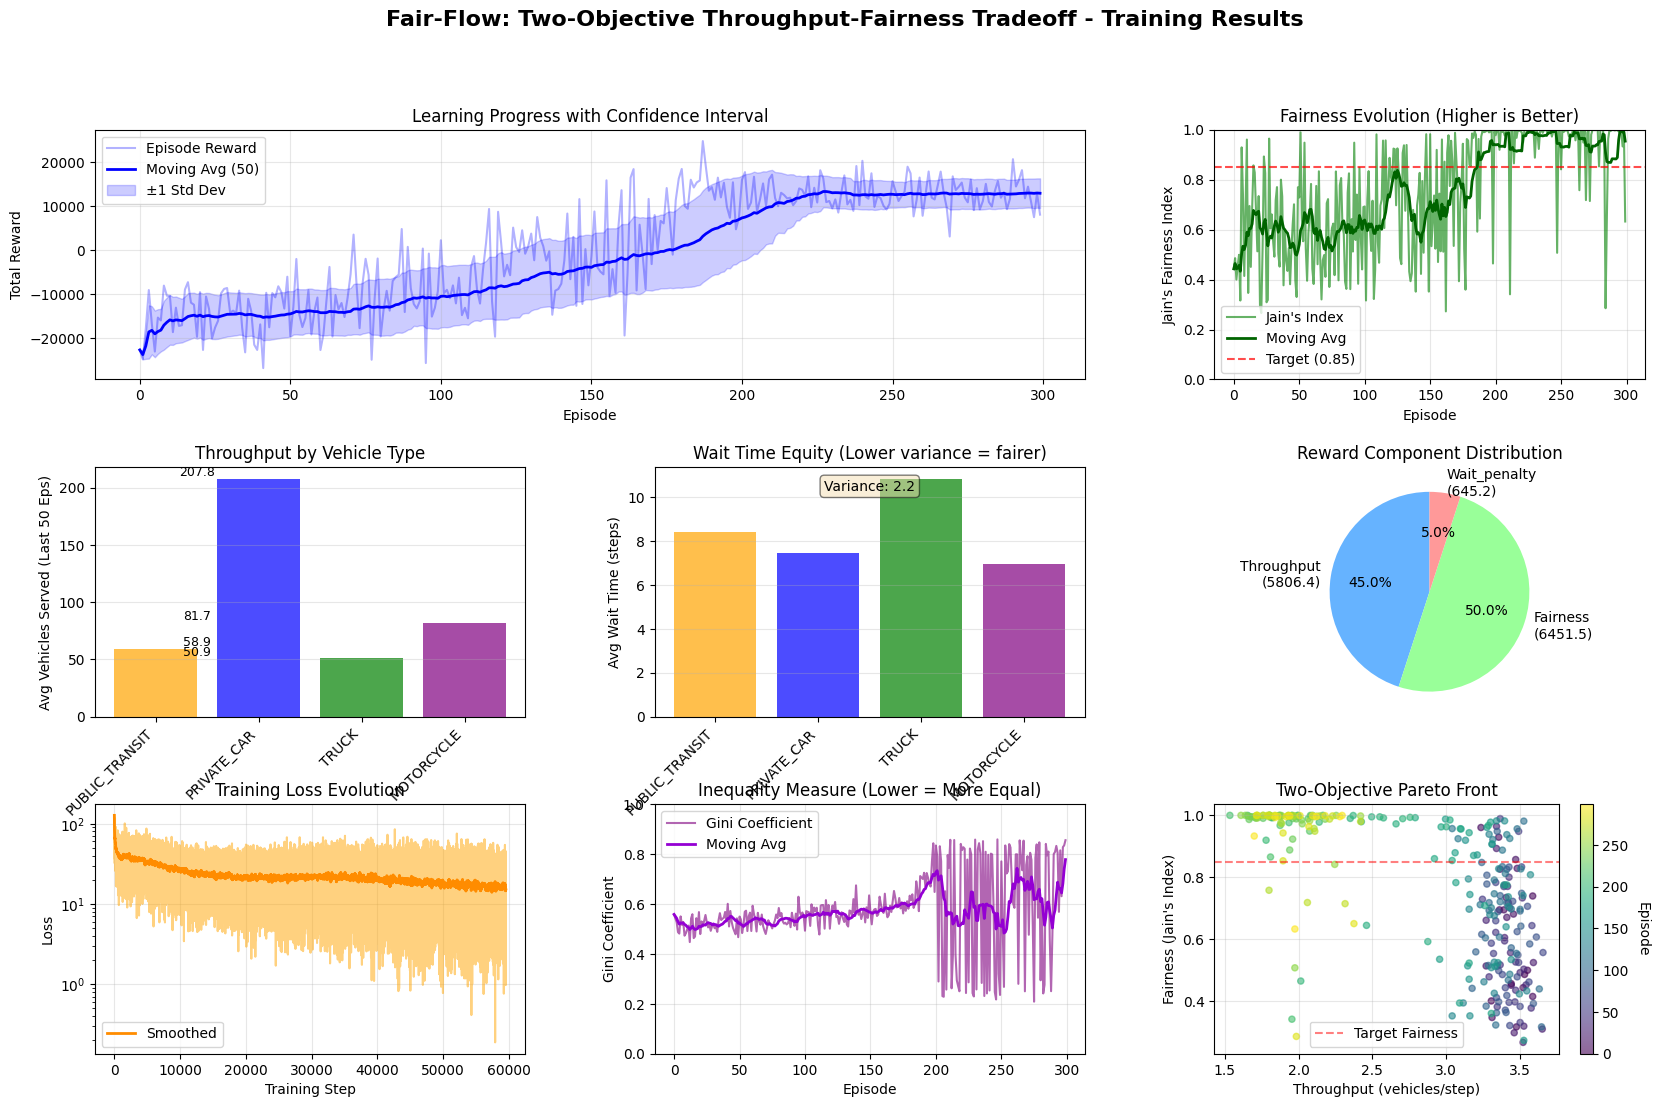


📊 COMPREHENSIVE TRAINING STATISTICS

🎯 Overall Performance:
   Final 50-episode average: 12903.06
   Best single episode: 24748.41
   Worst single episode: -26803.94
   Standard deviation (last 50): 3376.73

⚖️  Fairness Statistics:
   Final Jain's Index: 0.632
   Average (last 50): 0.941
   Best achieved: 1.000
   Target: 0.850
   ✅ Target fairness achieved!

🚗 Vehicle Service Statistics (Total):
   PUBLIC_TRANSIT : 24,831 vehicles
   └─ Avg wait time: 7.0 steps
   PRIVATE_CAR    : 88,680 vehicles
   └─ Avg wait time: 4.9 steps
   TRUCK          : 21,802 vehicles
   └─ Avg wait time: 13.0 steps
   MOTORCYCLE     : 35,187 vehicles
   └─ Avg wait time: 5.3 steps

🎯 Two-Objective Scores (Last 50 Episodes):
   Throughput: 1.997 vehicles/step
   Fairness: 0.941 (Jain's Index)


In [ ]:
results=full_training_fairflow()

In [ ]:
# Load the final model (best checkpoint)
ckpt = torch.load('final_fairflow_traffic_model.pth', map_location='cpu', weights_only=False)

# It's a dict — extract just the model weights
agent.q_network.load_state_dict(ckpt['model_state_dict'])
print("Loaded successfully!")

# Save cleanly as weights-only
torch.save(agent.q_network.state_dict(), 'fairflow_model.pth')
from google.colab import files
files.download('fairflow_model.pth')

Loaded successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 5: Throughput-Only Baseline for Comparison
"""
This baseline optimizes PURELY for throughput, ignoring fairness completely.
This will show the cost of fairness by comparing to an efficiency-first approach.
"""

class ThroughputOnlyEnvironment(FairFlowTrafficEnvironment):
    """Environment that rewards only throughput, ignoring fairness"""

    def __init__(self, config=None):
        super().__init__(config)

    def _calculate_reward(self, action, info):
        """
        THROUGHPUT-ONLY reward: Maximize vehicles served, ignore fairness
        This is the traditional RL traffic control objective
        """
        reward = 0

        # 1. THROUGHPUT - Pure vehicle count (no fairness weighting)
        total_served = sum(info['vehicles_served'].values())

        # Reward scales with vehicles served
        throughput_reward = total_served * 10

        # Bonus for serving fast vehicles (they clear quickly)
        cars_served = info['vehicles_served'].get(VehicleType.PRIVATE_CAR, 0)
        motorcycles_served = info['vehicles_served'].get(VehicleType.MOTORCYCLE, 0)
        throughput_reward += (cars_served + motorcycles_served) * 2

        reward += throughput_reward

        # 2. WAIT TIME PENALTY - Penalize total wait only
        # (No per-type fairness consideration)
        total_wait = sum(
            sum(v['wait_time'] for v in self.queues[d][vt])
            for d in range(4)
            for vt in VehicleType
        )
        wait_penalty = total_wait * 0.5
        reward -= wait_penalty

        # 3. QUEUE OVERFLOW SAFETY
        max_queue = max(
            sum(len(self.queues[d][vt]) for vt in VehicleType)
            for d in range(4)
        )

        if max_queue >= self.max_queue_length * 0.9:
            reward -= 200  # Prevent overflow

        # 4. EFFICIENCY BONUS - Reward clearing queues fast
        if total_served > 5:
            reward += 50  # Bonus for high throughput

        return reward

class ThroughputOnlyAgent(FairFlowAgent):
    """Agent that only cares about throughput"""

    def __init__(self, state_size=36, action_size=2, config=None):
        super().__init__(state_size, action_size, config)

        print("=" * 80)
        print("🚗 Throughput-Only Baseline Agent Initialized")
        print("=" * 80)
        print(f"🎯 Objective: MAXIMIZE THROUGHPUT (no fairness)")
        print(f"📊 Architecture: Same as Fair-Flow (for fair comparison)")
        print(f"💡 Strategy: Serve vehicles as fast as possible")
        print("=" * 80)

def train_throughput_baseline(
    episodes=300,
    verbose=True,
    save_models=False,
    checkpoint_freq=50,
    use_temporal=True
):
    """
    Train throughput-only baseline for comparison with Fair-Flow

    This baseline shows what happens when we DON'T care about fairness
    """
    # Initialize environment and agent
    config = Config()
    config.use_temporal_features = use_temporal
    env = ThroughputOnlyEnvironment(config)

    state_size = 36 if use_temporal else 26
    agent = ThroughputOnlyAgent(state_size=state_size, action_size=2, config=config)

    # Tracking metrics
    episode_rewards = []
    vehicle_type_metrics = {
        vt: {'served': [], 'wait_times': []}
        for vt in VehicleType
    }

    # Fairness tracking (even though we don't optimize for it)
    jains_index_history = []
    gini_coefficient_history = []

    # Pareto front
    pareto_front = []

    best_reward = float('-inf')
    recent_rewards = deque(maxlen=100)

    print("=" * 80)
    print("🚗 Training THROUGHPUT-ONLY Baseline (No Fairness)")
    print("=" * 80)
    print(f"🎯 Objective: Pure efficiency (maximize vehicles served)")
    print(f"📊 State Space: {state_size} dimensions")
    print(f"🎮 Action Space: 2 actions (Keep/Switch)")
    print(f"⚠️  Fairness: NOT considered in reward")
    print("=" * 80)

    training_start_time = time.time()

    for episode in range(episodes):
        state, _ = env.reset()
        episode_reward = 0
        vehicles_served_by_type = {vt: 0 for vt in VehicleType}
        steps = 0

        while True:
            action = agent.act(state, training=True)
            next_state, reward, done, _, info = env.step(action)

            agent.remember(state, action, reward, next_state, done, info)
            loss = agent.replay()

            episode_reward += reward
            steps += 1

            for vt in VehicleType:
                vehicles_served_by_type[vt] += info['vehicles_served'].get(vt, 0)

            state = next_state
            if done:
                break

        # Record metrics
        episode_rewards.append(episode_reward)
        recent_rewards.append(episode_reward)

        # Calculate fairness (even though not optimized)
        wait_times_by_type = []
        for vt in VehicleType:
            type_waits = []
            for d in range(4):
                type_waits.extend([v['wait_time'] for v in env.queues[d][vt]])

            if type_waits:
                wait_times_by_type.append(np.mean(type_waits))
            else:
                wait_times_by_type.append(0.0)

        jains_index = calculate_jains_fairness_index(wait_times_by_type) if sum(wait_times_by_type) > 0 else 1.0
        jains_index_history.append(jains_index)

        # Calculate Gini
        all_wait_times = []
        for vt in VehicleType:
            if env.wait_time_by_type[vt]:
                all_wait_times.extend(env.wait_time_by_type[vt])

        if all_wait_times:
            gini = calculate_gini_coefficient(all_wait_times)
            gini_coefficient_history.append(gini)

        # Update vehicle type metrics
        for vt in VehicleType:
            vehicle_type_metrics[vt]['served'].append(vehicles_served_by_type[vt])

            if env.wait_time_by_type[vt]:
                avg_wait = np.mean(env.wait_time_by_type[vt])
                vehicle_type_metrics[vt]['wait_times'].append(avg_wait)

        # Pareto front
        efficiency = sum(vehicles_served_by_type.values()) / max(steps, 1)
        pareto_front.append((efficiency, jains_index))

        # Track best
        if episode_reward > best_reward:
            best_reward = episode_reward

        # Verbose output
        if verbose and (episode % 10 == 0 or episode < 10):
            avg_recent = np.mean(list(recent_rewards)[-20:]) if len(recent_rewards) >= 20 else np.mean(list(recent_rewards))
            stats = agent.get_advanced_stats()

            print(f"Episode {episode:4d} | "
                  f"Reward: {episode_reward:7.2f} | "
                  f"Avg20: {avg_recent:7.2f} | "
                  f"ε: {stats['epsilon']:.3f} | "
                  f"Jain's: {jains_index:.3f} | "
                  f"Served: {sum(vehicles_served_by_type.values()):3d} | "
                  f"Throughput: {efficiency:.2f}")

        # Checkpoint reporting
        if episode > 0 and episode % checkpoint_freq == 0:
            print(f"\n{'='*80}")
            print(f"📊 Throughput-Only Checkpoint - Episode {episode}")
            print(f"{'='*80}")

            recent_50 = episode_rewards[-50:]
            print(f"\n🎯 Performance:")
            print(f"   Avg reward (last 50): {np.mean(recent_50):.2f}")
            print(f"   Best reward: {best_reward:.2f}")

            # Fairness (unintended)
            if len(jains_index_history) >= 50:
                recent_jains = jains_index_history[-50:]
                print(f"\n⚖️  Fairness (NOT optimized):")
                print(f"   Jain's Index: {np.mean(recent_jains):.3f} (accidental)")

            # Throughput breakdown
            print(f"\n🚗 Vehicles Served (last 50 avg):")
            for vt in VehicleType:
                recent_served = vehicle_type_metrics[vt]['served'][-50:]
                if recent_served:
                    avg_served = np.mean(recent_served)
                    print(f"   {vt.name:15s}: {avg_served:6.2f}", end="")

                    if vehicle_type_metrics[vt]['wait_times']:
                        recent_waits = vehicle_type_metrics[vt]['wait_times'][-50:]
                        if recent_waits:
                            print(f" (Wait: {np.mean(recent_waits):.1f} steps)")
                    else:
                        print()

            # Efficiency
            recent_efficiency = np.mean([p[0] for p in pareto_front[-50:]])
            print(f"\n📈 Throughput: {recent_efficiency:.3f} vehicles/step")
            print(f"{'='*80}\n")

    # Training completed
    total_time = time.time() - training_start_time
    print(f"\n{'='*80}")
    print(f"🎉 THROUGHPUT-ONLY BASELINE COMPLETED!")
    print(f"{'='*80}")
    print(f"⏱️  Total time: {total_time/60:.1f} minutes")
    print(f"🏆 Best reward: {best_reward:.2f}")

    # Final analysis
    if len(episode_rewards) >= 100:
        last_100 = np.mean(episode_rewards[-100:])
        print(f"\n📊 FINAL PERFORMANCE:")
        print(f"   Last 100 episodes avg: {last_100:.2f}")

        if len(jains_index_history) >= 100:
            final_fairness = np.mean(jains_index_history[-100:])
            print(f"\n⚖️  FAIRNESS (unintended):")
            print(f"   Final Jain's Index: {final_fairness:.3f}")
            print(f"   ⚠️  Note: Fairness was NOT optimized")

    # Vehicle stats
    print("\n🚗 Total Vehicle Service:")
    for vt in VehicleType:
        total = sum(vehicle_type_metrics[vt]['served'])
        print(f"   {vt.name:15s}: {total:,} vehicles")

        if vehicle_type_metrics[vt]['wait_times']:
            avg_wait = np.mean(vehicle_type_metrics[vt]['wait_times'])
            print(f"   └─ Avg wait: {avg_wait:.1f} steps")

    # Final throughput
    if pareto_front:
        final_throughput = np.mean([p[0] for p in pareto_front[-50:]])
        final_fairness = np.mean([p[1] for p in pareto_front[-50:]])
        print(f"\n🎯 Final Metrics:")
        print(f"   Throughput: {final_throughput:.3f} vehicles/step")
        print(f"   Fairness: {final_fairness:.3f} (NOT optimized)")

    return {
        'agent': agent,
        'rewards': episode_rewards,
        'jains_index': jains_index_history,
        'gini_coefficient': gini_coefficient_history,
        'vehicle_metrics': vehicle_type_metrics,
        'pareto_front': pareto_front,
        'best_reward': best_reward,
        'training_time': total_time
    }

def compare_fairflow_vs_baseline(fairflow_results, baseline_results):
    """
    Compare Fair-Flow (fairness-optimized) vs Throughput-Only Baseline

    This creates the KEY FIGURE for your paper showing the tradeoff
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Fair-Flow vs Throughput-Only Baseline Comparison',
                 fontsize=16, fontweight='bold')

    # 1. Pareto Frontier Comparison
    ax1 = axes[0, 0]

    # Fair-Flow trajectory
    ff_pareto = np.array(fairflow_results['pareto_front'])
    baseline_pareto = np.array(baseline_results['pareto_front'])

    ax1.scatter(ff_pareto[:, 0], ff_pareto[:, 1],
               c=range(len(ff_pareto)), cmap='Blues',
               alpha=0.6, s=20, label='Fair-Flow')
    ax1.scatter(baseline_pareto[:, 0], baseline_pareto[:, 1],
               c=range(len(baseline_pareto)), cmap='Reds',
               alpha=0.6, s=20, label='Throughput-Only')

    # Target fairness line
    ax1.axhline(y=0.85, color='green', linestyle='--',
                alpha=0.5, label='Target Fairness')

    ax1.set_xlabel('Throughput (vehicles/step)')
    ax1.set_ylabel("Fairness (Jain's Index)")
    ax1.set_title('Pareto Frontier: The Tradeoff')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Fairness over episodes
    ax2 = axes[0, 1]
    ff_jains = fairflow_results['jains_index']
    bl_jains = baseline_results['jains_index']

    # Smooth
    window = 20
    ff_smooth = [np.mean(ff_jains[max(0,i-window):i+1]) for i in range(len(ff_jains))]
    bl_smooth = [np.mean(bl_jains[max(0,i-window):i+1]) for i in range(len(bl_jains))]

    ax2.plot(ff_smooth, 'b-', linewidth=2, label='Fair-Flow', alpha=0.8)
    ax2.plot(bl_smooth, 'r-', linewidth=2, label='Throughput-Only', alpha=0.8)
    ax2.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Target')

    ax2.set_xlabel('Episode')
    ax2.set_ylabel("Jain's Fairness Index")
    ax2.set_title('Fairness Evolution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])

    # 3. Throughput over episodes
    ax3 = axes[0, 2]
    ff_throughput = [p[0] for p in fairflow_results['pareto_front']]
    bl_throughput = [p[0] for p in baseline_results['pareto_front']]

    ff_t_smooth = [np.mean(ff_throughput[max(0,i-window):i+1]) for i in range(len(ff_throughput))]
    bl_t_smooth = [np.mean(bl_throughput[max(0,i-window):i+1]) for i in range(len(bl_throughput))]

    ax3.plot(ff_t_smooth, 'b-', linewidth=2, label='Fair-Flow', alpha=0.8)
    ax3.plot(bl_t_smooth, 'r-', linewidth=2, label='Throughput-Only', alpha=0.8)

    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Throughput (vehicles/step)')
    ax3.set_title('Throughput Evolution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Wait times by vehicle type - Fair-Flow
    ax4 = axes[1, 0]
    ff_metrics = fairflow_results['vehicle_metrics']
    vehicle_names = [vt.name for vt in VehicleType]
    colors = ['orange', 'blue', 'green', 'purple']

    ff_waits = []
    for vt in VehicleType:
        if ff_metrics[vt]['wait_times']:
            ff_waits.append(np.mean(ff_metrics[vt]['wait_times'][-50:]))
        else:
            ff_waits.append(0)

    bars1 = ax4.bar(range(len(vehicle_names)), ff_waits, color=colors, alpha=0.7)
    ax4.set_xticks(range(len(vehicle_names)))
    ax4.set_xticklabels(vehicle_names, rotation=45, ha='right')
    ax4.set_ylabel('Avg Wait Time (steps)')
    ax4.set_title('Fair-Flow: Wait Times by Type')
    ax4.grid(True, alpha=0.3, axis='y')

    # Show variance
    variance_ff = np.var(ff_waits) if len(ff_waits) > 1 else 0
    ax4.text(0.5, 0.95, f'Variance: {variance_ff:.1f}',
            transform=ax4.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

    # 5. Wait times by vehicle type - Baseline
    ax5 = axes[1, 1]
    bl_metrics = baseline_results['vehicle_metrics']

    bl_waits = []
    for vt in VehicleType:
        if bl_metrics[vt]['wait_times']:
            bl_waits.append(np.mean(bl_metrics[vt]['wait_times'][-50:]))
        else:
            bl_waits.append(0)

    bars2 = ax5.bar(range(len(vehicle_names)), bl_waits, color=colors, alpha=0.7)
    ax5.set_xticks(range(len(vehicle_names)))
    ax5.set_xticklabels(vehicle_names, rotation=45, ha='right')
    ax5.set_ylabel('Avg Wait Time (steps)')
    ax5.set_title('Throughput-Only: Wait Times by Type')
    ax5.grid(True, alpha=0.3, axis='y')

    # Show variance
    variance_bl = np.var(bl_waits) if len(bl_waits) > 1 else 0
    ax5.text(0.5, 0.95, f'Variance: {variance_bl:.1f}',
            transform=ax5.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

    # 6. Summary comparison table
    ax6 = axes[1, 2]
    ax6.axis('off')

    # Calculate final metrics
    ff_final_throughput = np.mean([p[0] for p in fairflow_results['pareto_front'][-50:]])
    bl_final_throughput = np.mean([p[0] for p in baseline_results['pareto_front'][-50:]])

    ff_final_fairness = np.mean(fairflow_results['jains_index'][-50:])
    bl_final_fairness = np.mean(baseline_results['jains_index'][-50:])

    throughput_diff = ((ff_final_throughput - bl_final_throughput) / bl_final_throughput) * 100
    fairness_diff = ((ff_final_fairness - bl_final_fairness) / bl_final_fairness) * 100

    # Create table
    table_data = [
        ['Metric', 'Fair-Flow', 'Throughput-Only', 'Difference'],
        ['─' * 15, '─' * 12, '─' * 15, '─' * 12],
        ['Throughput', f'{ff_final_throughput:.3f}', f'{bl_final_throughput:.3f}',
         f'{throughput_diff:+.1f}%'],
        ['Fairness', f'{ff_final_fairness:.3f}', f'{bl_final_fairness:.3f}',
         f'{fairness_diff:+.1f}%'],
        ['Wait Variance', f'{variance_ff:.1f}', f'{variance_bl:.1f}',
         f'{((variance_ff-variance_bl)/variance_bl)*100:+.1f}%'],
    ]

    table = ax6.table(cellText=table_data, cellLoc='left',
                     loc='center', bbox=[0, 0.3, 1, 0.6])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Color code
    for i in range(len(table_data)):
        for j in range(len(table_data[0])):
            cell = table[(i, j)]
            if i == 0:  # Header
                cell.set_facecolor('#4CAF50')
                cell.set_text_props(weight='bold', color='white')
            elif i == 1:  # Separator
                cell.set_facecolor('#f0f0f0')

    ax6.set_title('Summary Comparison\n(Last 50 Episodes)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print detailed comparison
    print("\n" + "="*80)
    print("📊 FAIR-FLOW VS THROUGHPUT-ONLY: DETAILED COMPARISON")
    print("="*80)

    print(f"\n🎯 THROUGHPUT:")
    print(f"   Fair-Flow:       {ff_final_throughput:.3f} vehicles/step")
    print(f"   Throughput-Only: {bl_final_throughput:.3f} vehicles/step")
    print(f"   Difference:      {throughput_diff:+.1f}%")
    print(f"   {'⚠️  Cost of fairness' if throughput_diff < 0 else '✅ Fairness is free!'}")

    print(f"\n⚖️  FAIRNESS:")
    print(f"   Fair-Flow:       {ff_final_fairness:.3f} (Jain's Index)")
    print(f"   Throughput-Only: {bl_final_fairness:.3f} (Jain's Index)")
    print(f"   Difference:      {fairness_diff:+.1f}%")
    print(f"   {'✅ Target achieved (≥0.85)' if ff_final_fairness >= 0.85 else '⚠️ Below target'}")

    print(f"\n📊 WAIT TIME EQUITY:")
    print(f"   Fair-Flow variance:       {variance_ff:.2f}")
    print(f"   Throughput-Only variance: {variance_bl:.2f}")
    print(f"   {'✅ More equitable' if variance_ff < variance_bl else '⚠️ Less equitable'}")

    print(f"\n🚗 PER-VEHICLE-TYPE COMPARISON:")
    for i, vt in enumerate(VehicleType):
        print(f"\n   {vt.name}:")
        print(f"      Fair-Flow wait:       {ff_waits[i]:.1f} steps")
        print(f"      Throughput-Only wait: {bl_waits[i]:.1f} steps")
        diff = ff_waits[i] - bl_waits[i]
        print(f"      Difference:           {diff:+.1f} steps")

    print("\n" + "="*80)
    print("💡 KEY FINDING:")
    print(f"   Achieving fairness (Jain's {ff_final_fairness:.3f}) costs")
    print(f"   {abs(throughput_diff):.1f}% in throughput compared to efficiency-first approach")
    print("="*80)

def run_baseline_comparison():
    """Run both systems and compare"""
    print("🚀 Running comprehensive comparison...")
    print("   This will take ~60-70 minutes total")
    print()

    # Train Fair-Flow
    print("="*80)
    print("STEP 1/2: Training Fair-Flow (Fairness-Optimized)")
    print("="*80)
    fairflow_results = train_fairflow_agent(
        episodes=300,
        verbose=False,  # Less verbose for cleaner output
        save_models=False,
        checkpoint_freq=100,
        use_temporal=True
    )

    print("\n" + "="*80)
    print("STEP 2/2: Training Throughput-Only Baseline")
    print("="*80)
    baseline_results = train_throughput_baseline(
        episodes=300,
        verbose=False,
        save_models=False,
        checkpoint_freq=100,
        use_temporal=True
    )

    # Compare
    print("\n" + "="*80)
    print("GENERATING COMPARISON PLOTS...")
    print("="*80)
    compare_fairflow_vs_baseline(fairflow_results, baseline_results)

    return fairflow_results, baseline_results

print("=" * 80)
print("✅ Throughput-Only Baseline Ready!")
print("=" * 80)
print("\n🎯 Available Functions:")
print("1. train_throughput_baseline() - Train efficiency-first baseline")
print("2. compare_fairflow_vs_baseline() - Compare Fair-Flow vs baseline")
print("3. run_baseline_comparison() - Run both and compare automatically")
print("\n💡 Usage:")
print("   # Train baseline only:")
print("   baseline_results = train_throughput_baseline(episodes=500)")
print()
print("   # Compare with existing Fair-Flow results:")
print("   compare_fairflow_vs_baseline(fairflow_results, baseline_results)")
print()
print("   # Run complete comparison (60-70 min):")
print("   ff_results, bl_results = run_baseline_comparison()")
print("=" * 80)

✅ Throughput-Only Baseline Ready!

🎯 Available Functions:
1. train_throughput_baseline() - Train efficiency-first baseline
2. compare_fairflow_vs_baseline() - Compare Fair-Flow vs baseline
3. run_baseline_comparison() - Run both and compare automatically

💡 Usage:
   # Train baseline only:
   baseline_results = train_throughput_baseline(episodes=500)

   # Compare with existing Fair-Flow results:
   compare_fairflow_vs_baseline(fairflow_results, baseline_results)

   # Run complete comparison (60-70 min):
   ff_results, bl_results = run_baseline_comparison()


In [ ]:
baseline_results = train_throughput_baseline(episodes=300)

🚦 Fair-Flow Two-Objective Agent Initialized
📊 Architecture:
   - Total parameters: 288,615
   - State size: 36
   - Action size: 2
   - Hidden dim: 128
   - Attention heads: 4

🎯 Training Configuration:
   - Epsilon decay: 40,000 steps
   - Learning rate: 0.0005
   - Gamma: 0.99
   - Batch size: 64
   - Buffer size: 100,000

🎯 Two-Objective Focus:
   - PRIMARY: Fairness (Jain's Index ≥ 0.85)
   - SECONDARY: Throughput (balanced service)

⚙️  Device: cuda
🚗 Throughput-Only Baseline Agent Initialized
🎯 Objective: MAXIMIZE THROUGHPUT (no fairness)
📊 Architecture: Same as Fair-Flow (for fair comparison)
💡 Strategy: Serve vehicles as fast as possible
🚗 Training THROUGHPUT-ONLY Baseline (No Fairness)
🎯 Objective: Pure efficiency (maximize vehicles served)
📊 State Space: 36 dimensions
🎮 Action Space: 2 actions (Keep/Switch)
⚠️  Fairness: NOT considered in reward
Episode    0 | Reward: 1506.00 | Avg20: 1506.00 | ε: 0.995 | Jain's: 0.250 | Served: 701 | Throughput: 3.50
Episode    1 | Reward: -

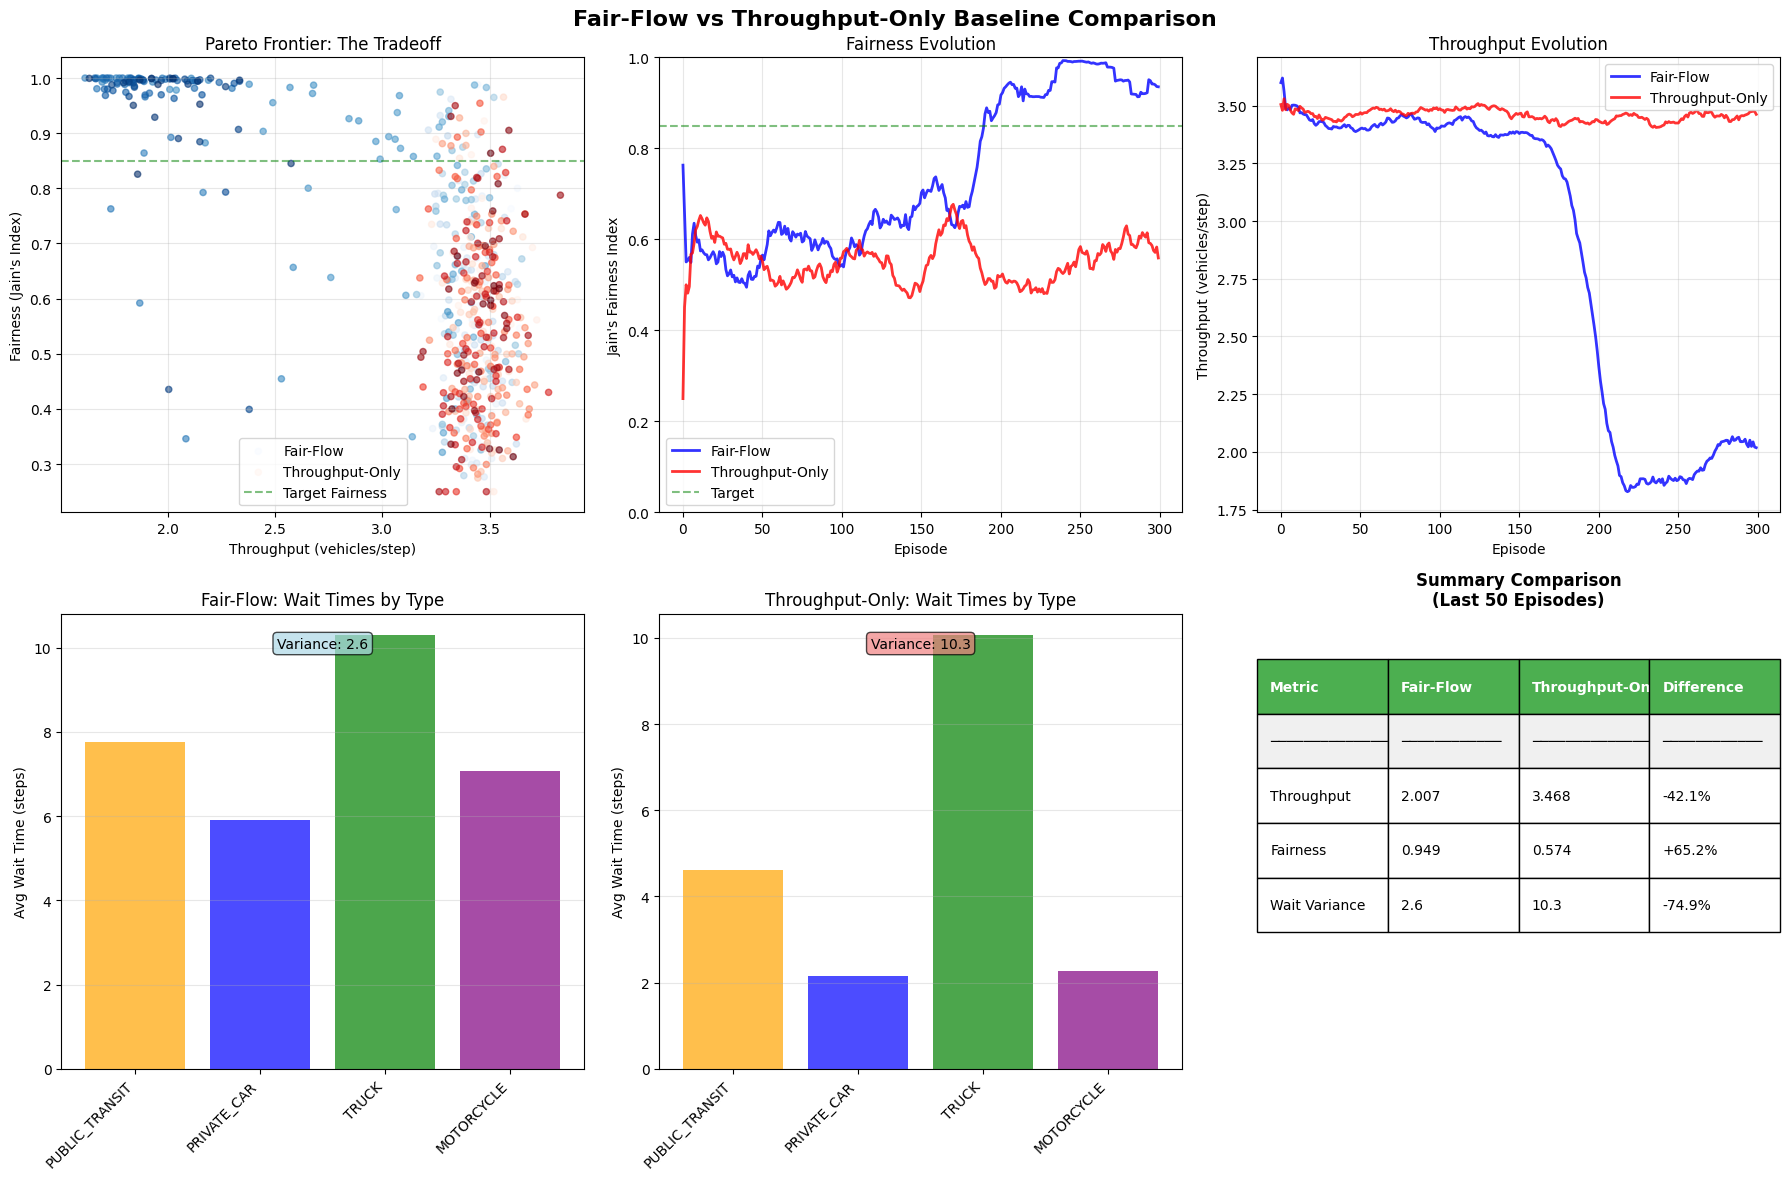


📊 FAIR-FLOW VS THROUGHPUT-ONLY: DETAILED COMPARISON

🎯 THROUGHPUT:
   Fair-Flow:       2.007 vehicles/step
   Throughput-Only: 3.468 vehicles/step
   Difference:      -42.1%
   ⚠️  Cost of fairness

⚖️  FAIRNESS:
   Fair-Flow:       0.949 (Jain's Index)
   Throughput-Only: 0.574 (Jain's Index)
   Difference:      +65.2%
   ✅ Target achieved (≥0.85)

📊 WAIT TIME EQUITY:
   Fair-Flow variance:       2.58
   Throughput-Only variance: 10.27
   ✅ More equitable

🚗 PER-VEHICLE-TYPE COMPARISON:

   PUBLIC_TRANSIT:
      Fair-Flow wait:       7.8 steps
      Throughput-Only wait: 4.6 steps
      Difference:           +3.2 steps

   PRIVATE_CAR:
      Fair-Flow wait:       5.9 steps
      Throughput-Only wait: 2.1 steps
      Difference:           +3.8 steps

   TRUCK:
      Fair-Flow wait:       10.3 steps
      Throughput-Only wait: 10.1 steps
      Difference:           +0.2 steps

   MOTORCYCLE:
      Fair-Flow wait:       7.1 steps
      Throughput-Only wait: 2.3 steps
      Difference:  

In [ ]:
compare_fairflow_vs_baseline(results, baseline_results)

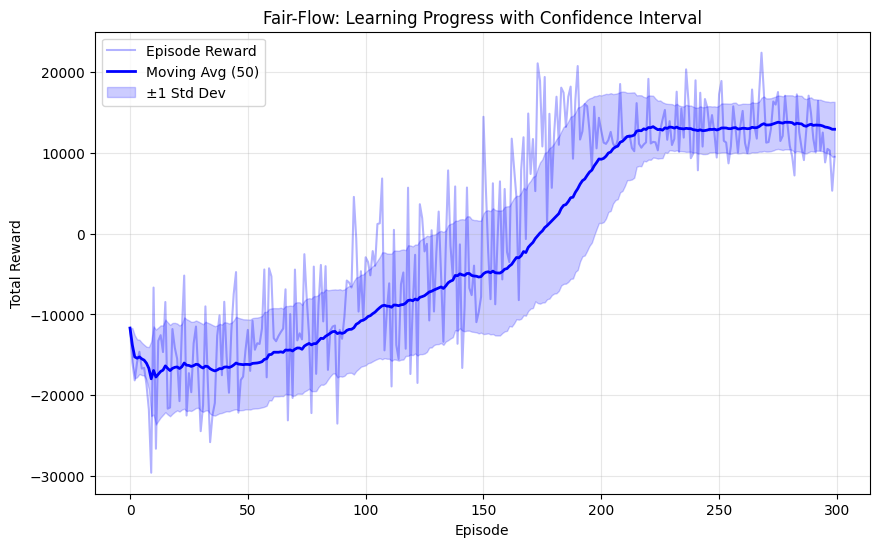

In [ ]:
# Cell to plot Learning curve with confidence interval (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results' variable is available from previous training run
if 'results' in locals() and results.get('rewards'):
    rewards = results['rewards']
    episodes = list(range(len(rewards)))

    window = 50
    moving_avg = []
    moving_std = []
    for i in range(len(rewards)):
        start_idx = max(0, i - window + 1)
        window_data = rewards[start_idx:i+1]
        moving_avg.append(np.mean(window_data))
        moving_std.append(np.std(window_data))

    moving_avg = np.array(moving_avg)
    moving_std = np.array(moving_std)

    plt.figure(figsize=(10, 6))
    plt.plot(episodes, rewards, alpha=0.3, color='blue', label='Episode Reward')
    plt.plot(episodes, moving_avg, 'b-', linewidth=2, label=f'Moving Avg ({window})')
    plt.fill_between(episodes, moving_avg - moving_std, moving_avg + moving_std,
                     alpha=0.2, color='blue', label='±1 Std Dev')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Fair-Flow: Learning Progress with Confidence Interval')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

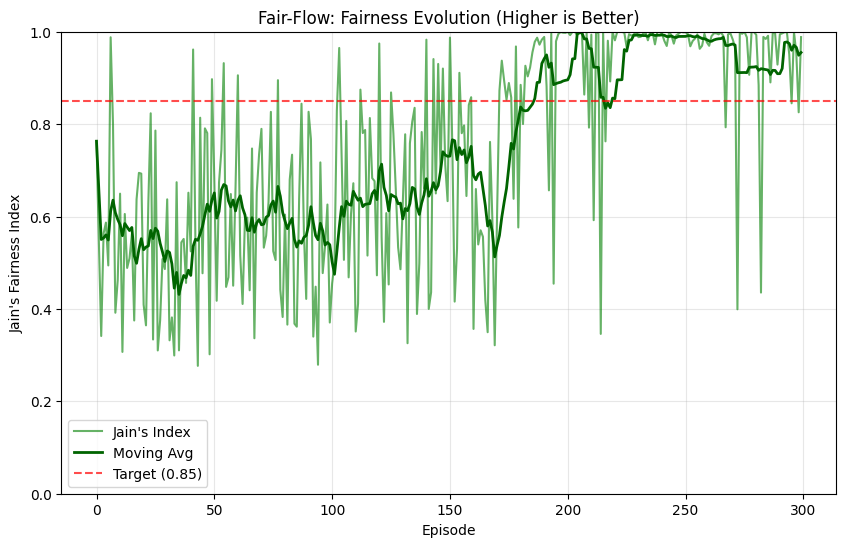

In [ ]:
# Cell to plot Fairness Evolution (Jain's Index) (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results' variable is available from previous training run
if 'results' in locals() and results.get('jains_index'):
    jains = results['jains_index']

    plt.figure(figsize=(10, 6))
    plt.plot(jains, 'green', alpha=0.6, label="Jain's Index")

    # Moving average
    if len(jains) > 10:
        window_j = 10
        jains_avg = []
        for i in range(len(jains)):
            start_idx = max(0, i - window_j + 1)
            jains_avg.append(np.mean(jains[start_idx:i+1]))
        plt.plot(jains_avg, 'darkgreen', linewidth=2, label='Moving Avg')

    # Target line (assuming Config is available)
    if 'config' in locals():
         plt.axhline(y=config.target_jain_index, color='red', linestyle='--', label=f'Target ({0.85:.2f})', alpha=0.7)
    else:
         plt.axhline(y=0.85, color='red', linestyle='--', label='Target (0.85)', alpha=0.7)


    plt.xlabel('Episode')
    plt.ylabel("Jain's Fairness Index")
    plt.title("Fair-Flow: Fairness Evolution (Higher is Better)")
    plt.ylim([0, 1])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

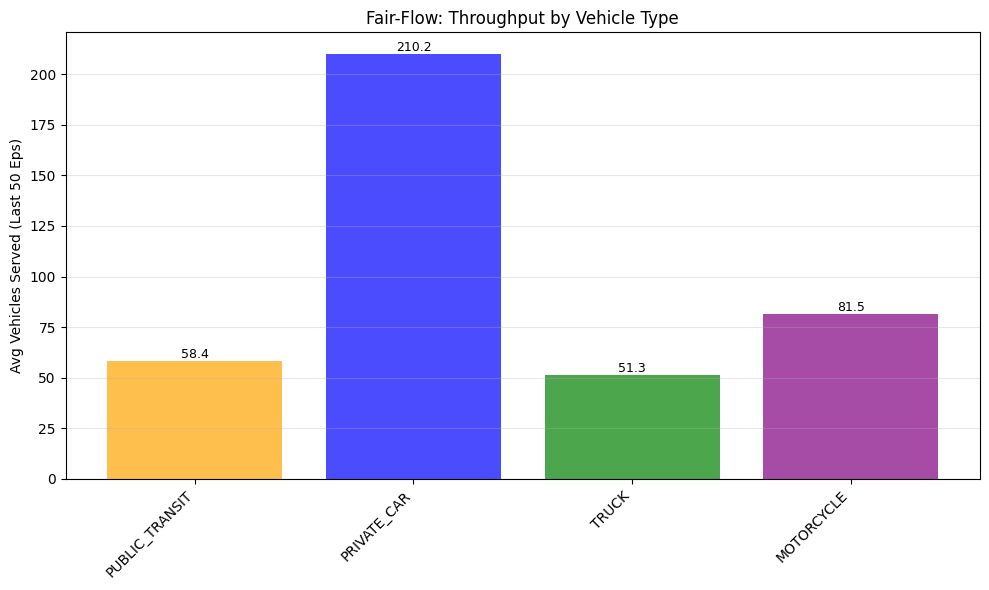

In [ ]:
# Cell to plot Vehicle Type Performance (Served) (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np
from enum import IntEnum # Assuming VehicleType is IntEnum

# Assuming 'results' and 'VehicleType' are available from previous training run
if 'results' in locals() and results.get('vehicle_metrics') and 'VehicleType' in locals():
    vehicle_metrics = results['vehicle_metrics']
    vehicle_names = [vt.name for vt in VehicleType]
    colors_vt = ['orange', 'blue', 'green', 'purple'] # Define colors again if not global

    avg_served = []
    for vt in VehicleType:
        if vehicle_metrics[vt]['served']:
            avg_served.append(np.mean(vehicle_metrics[vt]['served'][-50:])) # Using last 50 as in original plot
        else:
            avg_served.append(0)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(vehicle_names)), avg_served, color=colors_vt, alpha=0.7)
    plt.xticks(range(len(vehicle_names)), vehicle_names, rotation=45, ha='right')
    plt.ylabel('Avg Vehicles Served (Last 50 Eps)')
    plt.title('Fair-Flow: Throughput by Vehicle Type')
    plt.grid(True, alpha=0.3, axis='y')

    for bar, value in zip(bars, avg_served):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{value:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout() # Adjust layout for rotated labels
    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

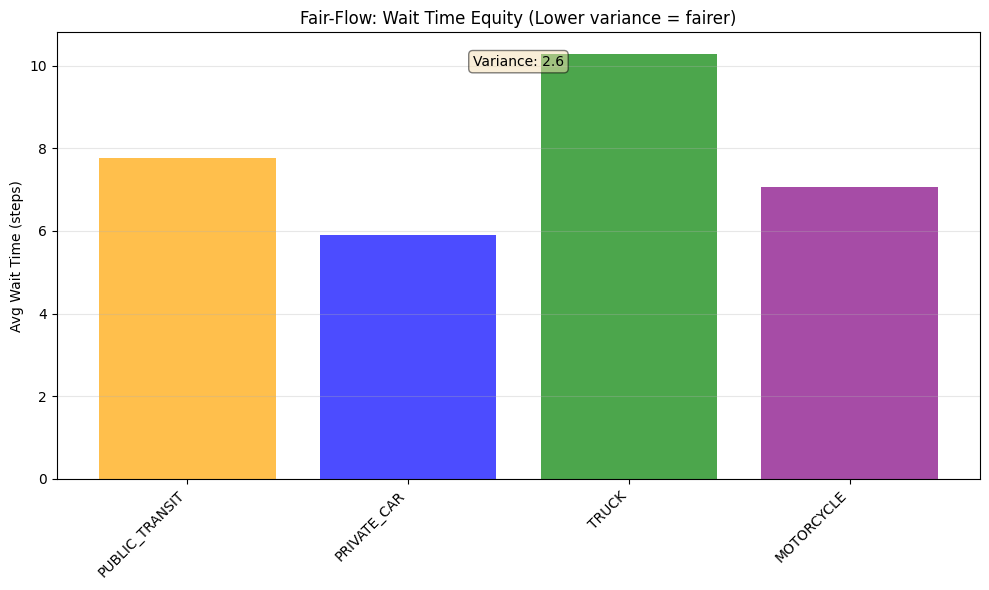

In [ ]:
# Cell to plot Fairness by Vehicle Type (Wait Times) (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np
from enum import IntEnum # Assuming VehicleType is IntEnum

# Assuming 'results' and 'VehicleType' are available from previous training run
if 'results' in locals() and results.get('fairness_per_type') and 'VehicleType' in locals():
    fairness_data = results['fairness_per_type']
    vehicle_names = [vt.name for vt in VehicleType]
    colors_vt = ['orange', 'blue', 'green', 'purple'] # Define colors again if not global

    wait_time_avgs = []
    for vt in VehicleType:
        if fairness_data[vt]:
            recent_waits = fairness_data[vt][-50:] # Using last 50 as in original plot
            wait_time_avgs.append(np.mean(recent_waits))
        else:
            wait_time_avgs.append(0)

    plt.figure(figsize=(10, 6))
    if sum(wait_time_avgs) > 0:
        bars2 = plt.bar(range(len(vehicle_names)), wait_time_avgs, color=colors_vt, alpha=0.7)
        plt.xticks(range(len(vehicle_names)), vehicle_names, rotation=45, ha='right')
        plt.ylabel('Avg Wait Time (steps)')
        plt.title('Fair-Flow: Wait Time Equity (Lower variance = fairer)')
        plt.grid(True, alpha=0.3, axis='y')

        # Show variance
        variance = np.var(wait_time_avgs) if len(wait_time_avgs) > 1 else 0
        plt.text(0.5, 0.95, f'Variance: {variance:.1f}',
                 transform=plt.gca().transAxes, ha='center', va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        plt.text(0.5, 0.5, 'No wait time data', ha='center', va='center', transform=plt.gca().transAxes)

    plt.tight_layout() # Adjust layout for rotated labels
    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

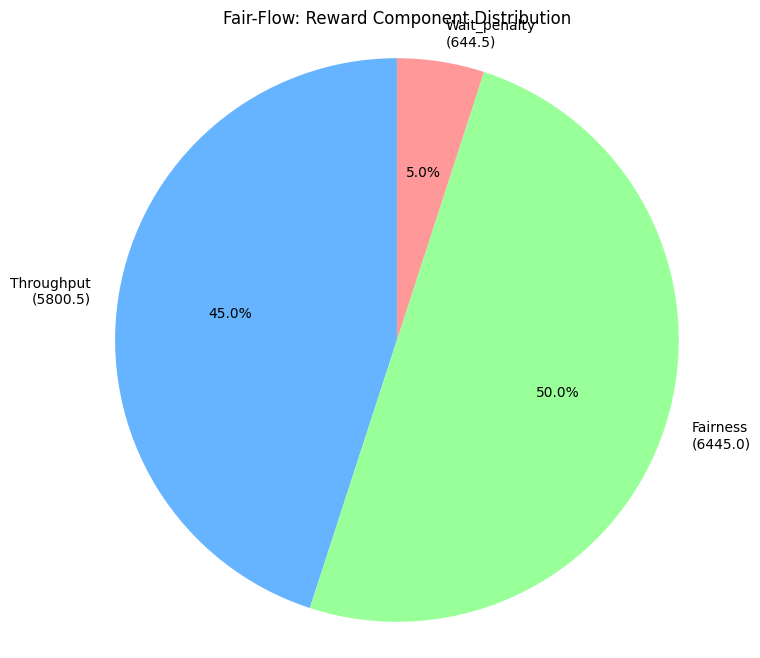

In [ ]:
# Cell to plot Reward Component Distribution (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results' variable is available from previous training run
if 'results' in locals() and results.get('reward_components'):
    reward_components = results['reward_components']

    components_avg = {}
    for key in reward_components:
        if reward_components[key]:
            # Using last 50 average absolute value as in original plot
            components_avg[key] = np.abs(np.mean(reward_components[key][-50:]))

    plt.figure(figsize=(8, 8))
    if components_avg and sum(components_avg.values()) > 0:
        sizes = list(components_avg.values())
        labels = [f'{k.capitalize()}\n({v:.1f})' for k, v in components_avg.items()]
        colors_pie = ['#66b3ff', '#99ff99', '#ff9999']  # 3 colors for 3 components

        plt.pie(sizes, labels=labels, colors=colors_pie,
                autopct='%1.1f%%', startangle=90)
        plt.title('Fair-Flow: Reward Component Distribution')
        plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    else:
         plt.text(0.5, 0.5, 'No reward component data', ha='center', va='center', transform=plt.gca().transAxes)

    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

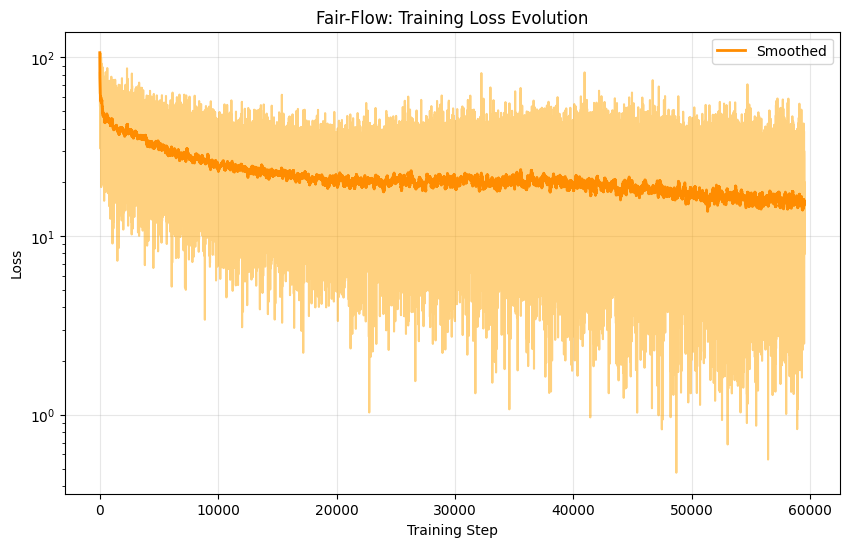

In [ ]:
# Cell to plot Training Loss (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results' variable is available from previous training run
if 'results' in locals() and results.get('losses'):
    losses = results['losses']

    plt.figure(figsize=(10, 6))
    plt.plot(losses, 'orange', alpha=0.5)

    if len(losses) > 100:
        smooth_window = 100
        smooth_losses = []
        for i in range(len(losses)):
            start_idx = max(0, i - smooth_window + 1)
            smooth_losses.append(np.mean(losses[start_idx:i+1]))
        plt.plot(smooth_losses, 'darkorange', linewidth=2, label='Smoothed')

    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('Fair-Flow: Training Loss Evolution')
    plt.yscale('log') # Use log scale as in the original plot
    plt.grid(True, alpha=0.3)
    if len(losses) > 100:
        plt.legend()

    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

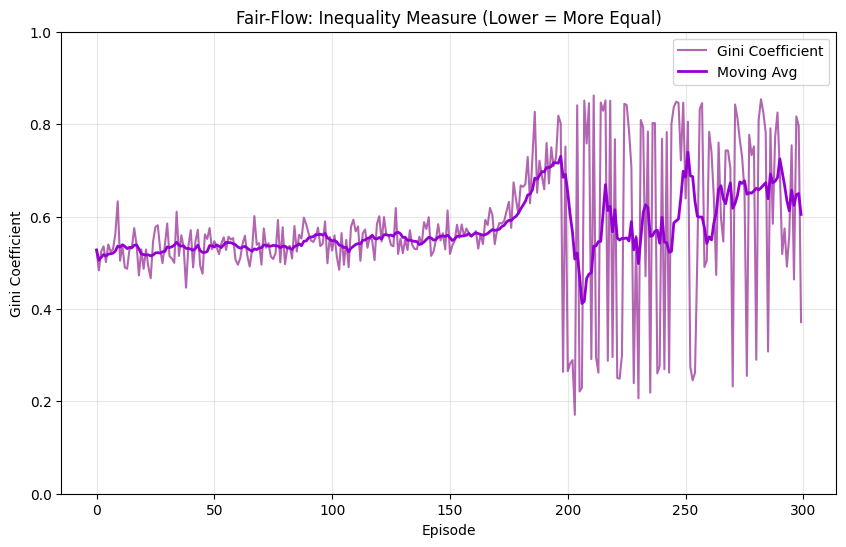

In [ ]:
# Cell to plot Gini Coefficient (Inequality) (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results' variable is available from previous training run
if 'results' in locals() and results.get('gini_coefficient'):
    gini = results['gini_coefficient']

    plt.figure(figsize=(10, 6))
    plt.plot(gini, 'purple', alpha=0.6, label='Gini Coefficient')

    if len(gini) > 10:
        smooth_gini = []
        for i in range(len(gini)):
            start_idx = max(0, i - 10 + 1)
            smooth_gini.append(np.mean(gini[start_idx:i+1]))
        plt.plot(smooth_gini, 'darkviolet', linewidth=2, label='Moving Avg')

    plt.xlabel('Episode')
    plt.ylabel('Gini Coefficient')
    plt.title('Fair-Flow: Inequality Measure (Lower = More Equal)')
    plt.ylim([0, 1])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

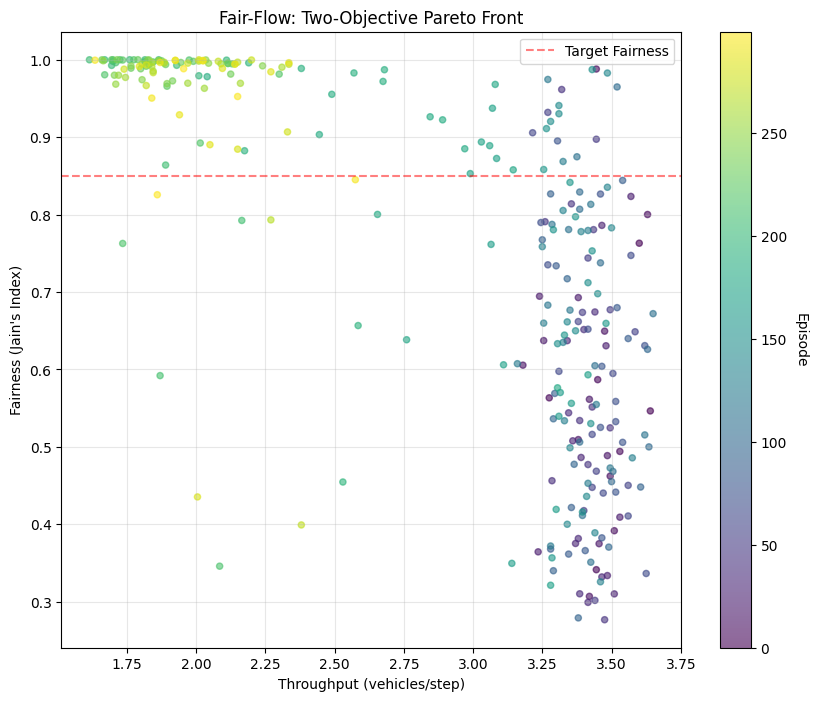

In [ ]:
# Cell to plot Pareto Front Visualization (2D) (from plot_fairflow_results)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results' variable is available from previous training run
if 'results' in locals() and results.get('pareto_front'):
    pareto = np.array(results['pareto_front'])

    plt.figure(figsize=(10, 8))
    # Color by episode
    colors_scatter = range(len(pareto))
    scatter = plt.scatter(pareto[:, 0], pareto[:, 1],
                          c=colors_scatter, cmap='viridis', alpha=0.6, s=20)

    plt.xlabel('Throughput (vehicles/step)')
    plt.ylabel("Fairness (Jain's Index)")
    plt.title('Fair-Flow: Two-Objective Pareto Front')
    plt.grid(True, alpha=0.3)

    # Add target fairness line (assuming Config is available)
    if 'config' in locals():
         plt.axhline(y=config.target_jain_index, color='red', linestyle='--', alpha=0.5, label='Target Fairness')
    else:
         plt.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target Fairness')

    plt.legend()

    cbar = plt.colorbar(scatter)
    cbar.set_label('Episode', rotation=270, labelpad=15)

    plt.show()
else:
    print("Please run the training cell first to generate 'results'.")

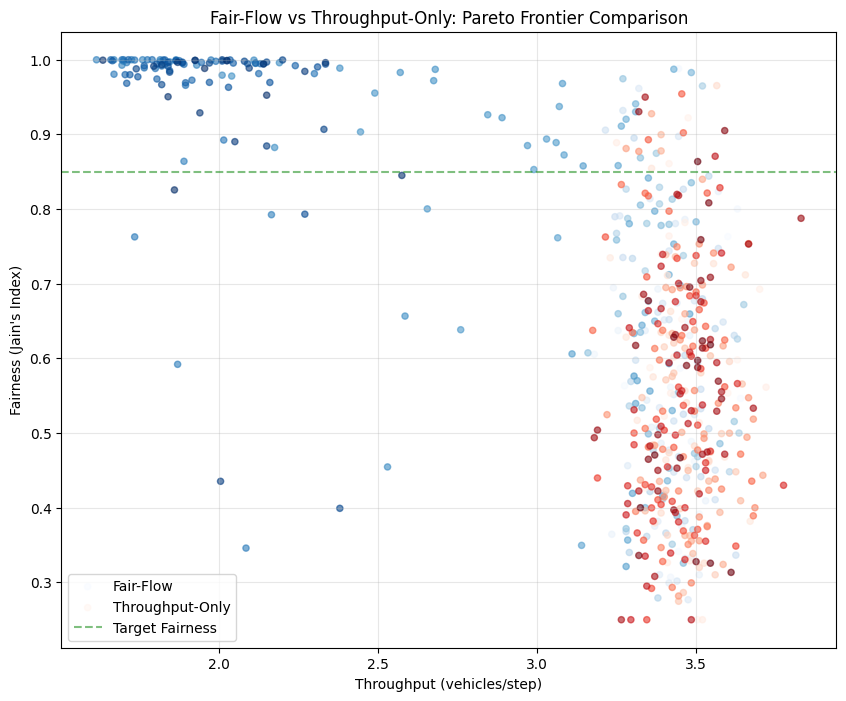

In [ ]:
# Cell to plot Pareto Frontier Comparison (from compare_fairflow_vs_baseline)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fairflow_results' and 'baseline_results' are available
if 'results' in locals() and results.get('pareto_front') and \
   'baseline_results' in locals() and baseline_results.get('pareto_front'):

    ff_pareto = np.array(results['pareto_front'])
    baseline_pareto = np.array(baseline_results['pareto_front'])

    plt.figure(figsize=(10, 8))
    plt.scatter(ff_pareto[:, 0], ff_pareto[:, 1],
                c=range(len(ff_pareto)), cmap='Blues',
                alpha=0.6, s=20, label='Fair-Flow')
    plt.scatter(baseline_pareto[:, 0], baseline_pareto[:, 1],
                c=range(len(baseline_pareto)), cmap='Reds',
                alpha=0.6, s=20, label='Throughput-Only')

    # Target fairness line (assuming Config is available)
    if 'config' in locals():
         plt.axhline(y=config.target_jain_index, color='green', linestyle='--',
                     alpha=0.5, label='Target Fairness')
    else:
         plt.axhline(y=0.85, color='green', linestyle='--',
                     alpha=0.5, label='Target Fairness')

    plt.xlabel('Throughput (vehicles/step)')
    plt.ylabel("Fairness (Jain's Index)")
    plt.title('Fair-Flow vs Throughput-Only: Pareto Frontier Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Please run both training functions ('full_training_fairflow' and 'train_throughput_baseline') first.")

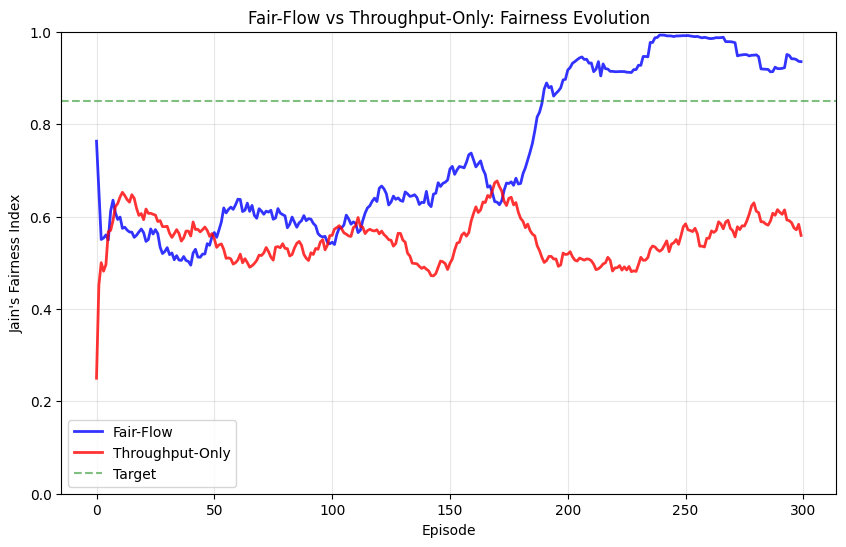

In [ ]:
# Cell to plot Fairness Evolution Comparison (from compare_fairflow_vs_baseline)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fairflow_results' and 'baseline_results' are available
if 'results' in locals() and results.get('jains_index') and \
   'baseline_results' in locals() and baseline_results.get('jains_index'):

    ff_jains = results['jains_index']
    bl_jains = baseline_results['jains_index']

    plt.figure(figsize=(10, 6))
    window = 20 # Smoothing window as in original plot
    ff_smooth = [np.mean(ff_jains[max(0,i-window):i+1]) for i in range(len(ff_jains))]
    bl_smooth = [np.mean(bl_jains[max(0,i-window):i+1]) for i in range(len(bl_jains))]

    plt.plot(ff_smooth, 'b-', linewidth=2, label='Fair-Flow', alpha=0.8)
    plt.plot(bl_smooth, 'r-', linewidth=2, label='Throughput-Only', alpha=0.8)

    # Target fairness line (assuming Config is available)
    if 'config' in locals():
         plt.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Target')
    else:
         plt.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Target')


    plt.xlabel('Episode')
    plt.ylabel("Jain's Fairness Index")
    plt.title('Fair-Flow vs Throughput-Only: Fairness Evolution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1])
    plt.show()
else:
    print("Please run both training functions ('full_training_fairflow' and 'train_throughput_baseline') first.")

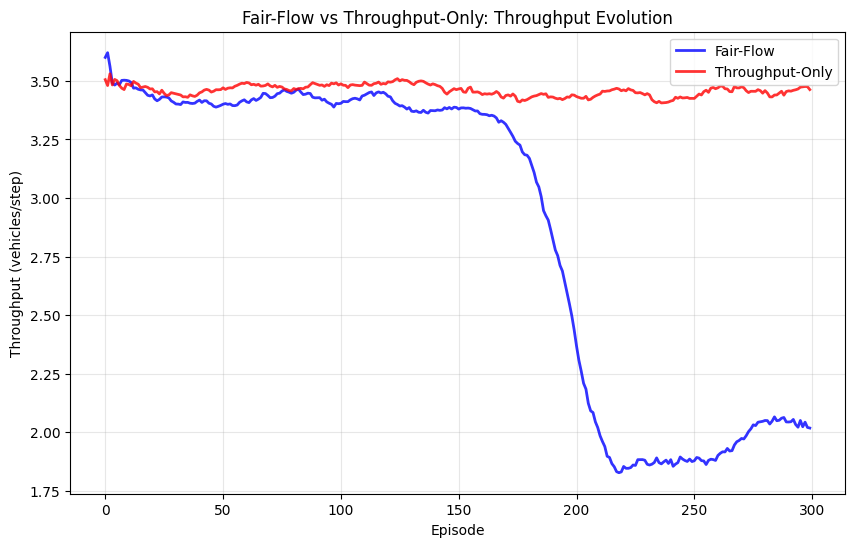

In [ ]:
# Cell to plot Throughput Evolution Comparison (from compare_fairflow_vs_baseline)
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'fairflow_results' and 'baseline_results' are available
if 'results' in locals() and results.get('pareto_front') and \
   'baseline_results' in locals() and baseline_results.get('pareto_front'):

    ff_throughput = [p[0] for p in results['pareto_front']]
    bl_throughput = [p[0] for p in baseline_results['pareto_front']]

    plt.figure(figsize=(10, 6))
    window = 20 # Smoothing window as in original plot
    ff_t_smooth = [np.mean(ff_throughput[max(0,i-window):i+1]) for i in range(len(ff_throughput))]
    bl_t_smooth = [np.mean(bl_throughput[max(0,i-window):i+1]) for i in range(len(bl_throughput))]

    plt.plot(ff_t_smooth, 'b-', linewidth=2, label='Fair-Flow', alpha=0.8)
    plt.plot(bl_t_smooth, 'r-', linewidth=2, label='Throughput-Only', alpha=0.8)

    plt.xlabel('Episode')
    plt.ylabel('Throughput (vehicles/step)')
    plt.title('Fair-Flow vs Throughput-Only: Throughput Evolution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Please run both training functions ('full_training_fairflow' and 'train_throughput_baseline') first.")

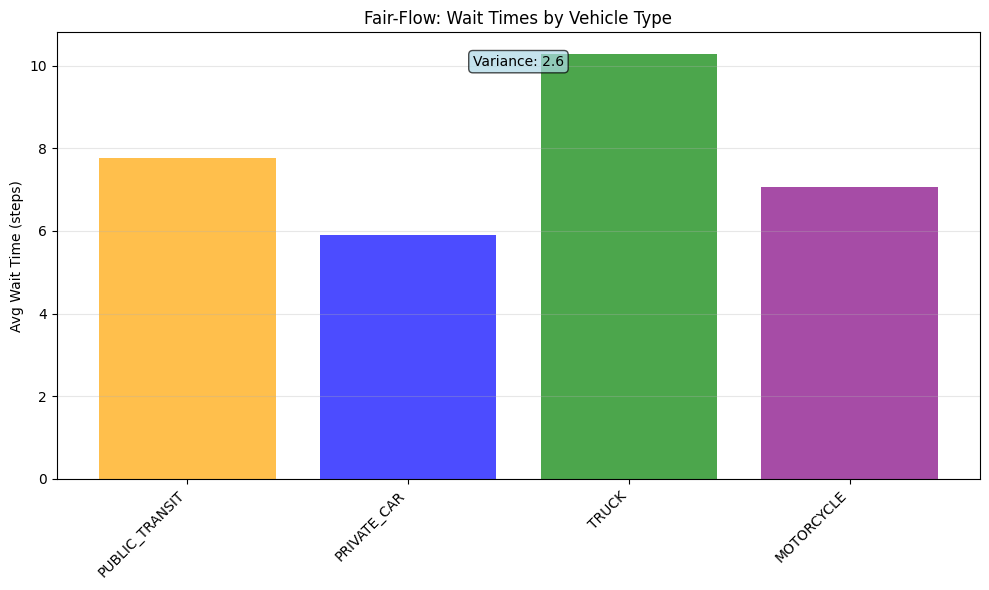

In [ ]:
# Cell to plot Wait times by vehicle type - Fair-Flow (from compare_fairflow_vs_baseline)
import matplotlib.pyplot as plt
import numpy as np
from enum import IntEnum # Assuming VehicleType is IntEnum

# Assuming 'fairflow_results' and 'VehicleType' are available
if 'results' in locals() and results.get('vehicle_metrics') and 'VehicleType' in locals():
    ff_metrics = results['vehicle_metrics']
    vehicle_names = [vt.name for vt in VehicleType]
    colors = ['orange', 'blue', 'green', 'purple'] # Define colors again if not global

    ff_waits = []
    for vt in VehicleType:
        if ff_metrics[vt]['wait_times']:
            ff_waits.append(np.mean(ff_metrics[vt]['wait_times'][-50:])) # Using last 50 as in original plot
        else:
            ff_waits.append(0)

    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(range(len(vehicle_names)), ff_waits, color=colors, alpha=0.7)
    plt.xticks(range(len(vehicle_names)), vehicle_names, rotation=45, ha='right')
    plt.ylabel('Avg Wait Time (steps)')
    plt.title('Fair-Flow: Wait Times by Vehicle Type')
    plt.grid(True, alpha=0.3, axis='y')

    # Show variance
    variance_ff = np.var(ff_waits) if len(ff_waits) > 1 else 0
    plt.text(0.5, 0.95, f'Variance: {variance_ff:.1f}',
             transform=plt.gca().transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

    plt.tight_layout() # Adjust layout for rotated labels
    plt.show()
else:
    print("Please run 'full_training_fairflow' first.")

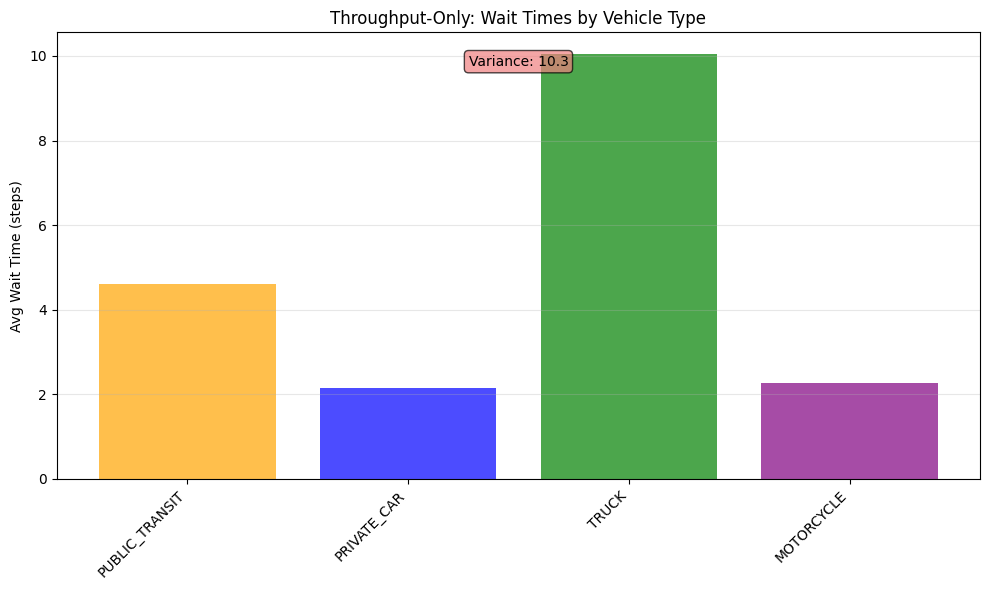

In [ ]:
# Cell to plot Wait times by vehicle type - Baseline (from compare_fairflow_vs_baseline)
import matplotlib.pyplot as plt
import numpy as np
from enum import IntEnum # Assuming VehicleType is IntEnum

# Assuming 'baseline_results' and 'VehicleType' are available
if 'baseline_results' in locals() and baseline_results.get('vehicle_metrics') and 'VehicleType' in locals():
    bl_metrics = baseline_results['vehicle_metrics']
    vehicle_names = [vt.name for vt in VehicleType]
    colors = ['orange', 'blue', 'green', 'purple'] # Define colors again if not global

    bl_waits = []
    for vt in VehicleType:
        if bl_metrics[vt]['wait_times']:
            bl_waits.append(np.mean(bl_metrics[vt]['wait_times'][-50:])) # Using last 50 as in original plot
        else:
            bl_waits.append(0)

    plt.figure(figsize=(10, 6))
    bars2 = plt.bar(range(len(vehicle_names)), bl_waits, color=colors, alpha=0.7)
    plt.xticks(range(len(vehicle_names)), vehicle_names, rotation=45, ha='right')
    plt.ylabel('Avg Wait Time (steps)')
    plt.title('Throughput-Only: Wait Times by Vehicle Type')
    plt.grid(True, alpha=0.3, axis='y')

    # Show variance
    variance_bl = np.var(bl_waits) if len(bl_waits) > 1 else 0
    plt.text(0.5, 0.95, f'Variance: {variance_bl:.1f}',
             transform=plt.gca().transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

    plt.tight_layout() # Adjust layout for rotated labels
    plt.show()
else:
    print("Please run 'train_throughput_baseline' first.")

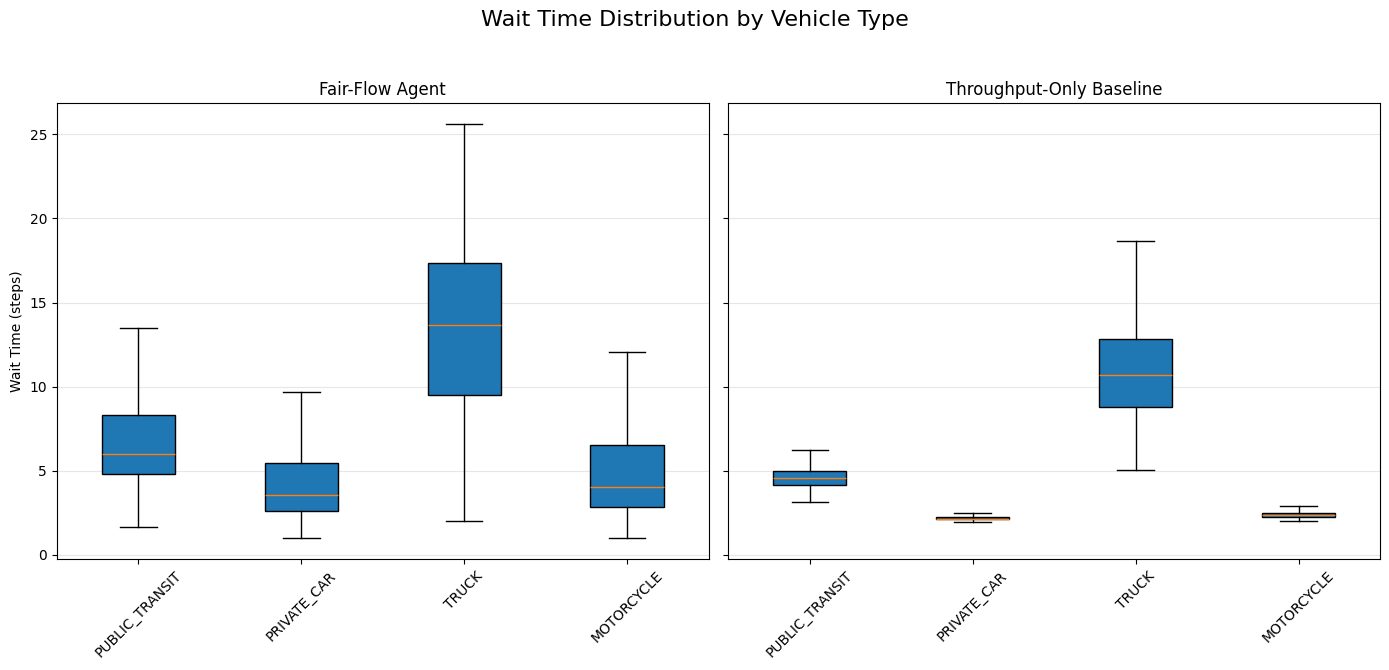


--- Wait Time Distribution Summary (Median and IQR) ---
Fair-Flow:
  PUBLIC_TRANSIT : Median=6.0, IQR=(4.8-8.3)
  PRIVATE_CAR    : Median=3.5, IQR=(2.6-5.4)
  TRUCK          : Median=13.7, IQR=(9.5-17.4)
  MOTORCYCLE     : Median=4.1, IQR=(2.9-6.5)

Throughput-Only Baseline:
  PUBLIC_TRANSIT : Median=4.6, IQR=(4.1-5.0)
  PRIVATE_CAR    : Median=2.2, IQR=(2.1-2.3)
  TRUCK          : Median=10.7, IQR=(8.8-12.8)
  MOTORCYCLE     : Median=2.3, IQR=(2.2-2.5)


In [ ]:
# Cell to plot Wait Time Distribution by Vehicle Type (Box Plots)

import matplotlib.pyplot as plt
import numpy as np
from enum import IntEnum # Assuming VehicleType is IntEnum
import pandas as pd

# Assuming 'fairflow_results' and 'baseline_results' are available from previous runs
if 'results' in locals() and results.get('fairness_per_type') and \
   'baseline_results' in locals() and baseline_results.get('vehicle_metrics') and \
   'VehicleType' in locals():

    ff_wait_data = results['fairness_per_type']
    bl_wait_data = baseline_results['vehicle_metrics']

    # Prepare data for box plots
    ff_data_to_plot = [ff_wait_data[vt] for vt in VehicleType]
    bl_data_to_plot = [bl_wait_data[vt]['wait_times'] for vt in VehicleType]
    vehicle_names = [vt.name for vt in VehicleType]

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    fig.suptitle('Wait Time Distribution by Vehicle Type', fontsize=16)

    # Fair-Flow Box Plots
    if any(ff_data_to_plot): # Check if there's any data
        axes[0].boxplot(ff_data_to_plot, patch_artist=True, labels=vehicle_names, showfliers=False) # showfliers=False to avoid extreme outliers cluttering the plot
        axes[0].set_title('Fair-Flow Agent')
        axes[0].set_ylabel('Wait Time (steps)')
        axes[0].grid(True, alpha=0.3, axis='y')
        axes[0].tick_params(axis='x', rotation=45)
    else:
        axes[0].text(0.5, 0.5, 'No Fair-Flow wait time data', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)


    # Throughput-Only Baseline Box Plots
    if any(bl_data_to_plot): # Check if there's any data
        axes[1].boxplot(bl_data_to_plot, patch_artist=True, labels=vehicle_names, showfliers=False)
        axes[1].set_title('Throughput-Only Baseline')
        axes[1].grid(True, alpha=0.3, axis='y')
        axes[1].tick_params(axis='x', rotation=45)
    else:
         axes[1].text(0.5, 0.5, 'No Baseline wait time data', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)


    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

    print("\n--- Wait Time Distribution Summary (Median and IQR) ---")
    print("Fair-Flow:")
    for i, vt in enumerate(VehicleType):
        if ff_wait_data[vt]:
            median = np.median(ff_wait_data[vt])
            q1 = np.percentile(ff_wait_data[vt], 25)
            q3 = np.percentile(ff_wait_data[vt], 75)
            print(f"  {vt.name:<15}: Median={median:.1f}, IQR=({q1:.1f}-{q3:.1f})")
        else:
            print(f"  {vt.name:<15}: No data")

    print("\nThroughput-Only Baseline:")
    for i, vt in enumerate(VehicleType):
        if bl_wait_data[vt]['wait_times']:
            median = np.median(bl_wait_data[vt]['wait_times'])
            q1 = np.percentile(bl_wait_data[vt]['wait_times'], 25)
            q3 = np.percentile(bl_wait_data[vt]['wait_times'], 75)
            print(f"  {vt.name:<15}: Median={median:.1f}, IQR=({q1:.1f}-{q3:.1f})")
        else:
            print(f"  {vt.name:<15}: No data")


else:
    print("Please run both training functions ('full_training_fairflow' and 'train_throughput_baseline') first.")

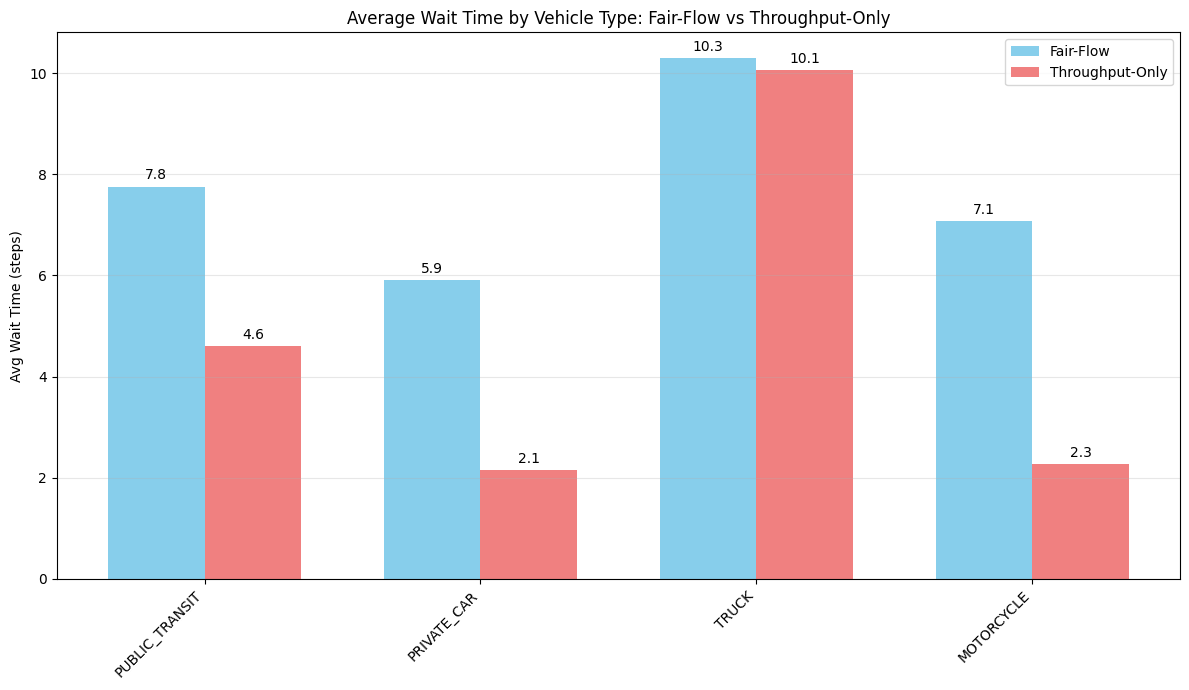

In [ ]:
# Cell to plot Combined Average Wait Times by Vehicle Type (Grouped Bar Chart)
import matplotlib.pyplot as plt
import numpy as np
from enum import IntEnum # Assuming VehicleType is IntEnum

# Assuming 'fairflow_results' and 'baseline_results' and 'VehicleType' are available
if 'results' in locals() and results.get('fairness_per_type') and \
   'baseline_results' in locals() and baseline_results.get('vehicle_metrics') and \
   'VehicleType' in locals():

    ff_wait_data = results['fairness_per_type']
    bl_wait_data = baseline_results['vehicle_metrics']

    vehicle_names = [vt.name for vt in VehicleType]
    colors = ['orange', 'blue', 'green', 'purple'] # Colors for vehicle types

    ff_waits = []
    for vt in VehicleType:
        if ff_wait_data[vt]:
            ff_waits.append(np.mean(ff_wait_data[vt][-50:])) # Using last 50 as in original plot
        else:
            ff_waits.append(0)

    bl_waits = []
    for vt in VehicleType:
        if bl_wait_data[vt]['wait_times']:
            bl_waits.append(np.mean(bl_wait_data[vt]['wait_times'][-50:])) # Using last 50 as in original plot
        else:
            bl_waits.append(0)

    x = np.arange(len(vehicle_names)) # the label locations
    width = 0.35 # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 7))

    # Plotting Fair-Flow bars
    rects1 = ax.bar(x - width/2, ff_waits, width, label='Fair-Flow', color='skyblue')

    # Plotting Baseline bars
    rects2 = ax.bar(x + width/2, bl_waits, width, label='Throughput-Only', color='lightcoral')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Avg Wait Time (steps)')
    ax.set_title('Average Wait Time by Vehicle Type: Fair-Flow vs Throughput-Only')
    ax.set_xticks(x)
    ax.set_xticklabels(vehicle_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Function to auto-label the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

else:
    print("Please run both training functions ('full_training_fairflow' and 'train_throughput_baseline') first.")